In [1]:
import numpy as np

import sys
sys.path.append("../src")
import energy_spectra as es
from energy_spectra import load_spectra, restrict_to_time

In [4]:
# load all available caches using a small table of filenames / labels
file_map = {
    "baseline": "spectra_cache_baseline_unroll30.npz",
    "bare": "spectra_cache_bare-minimum_unroll30.npz",
    "sfc": "spectra_cache_sfconly_unroll30.npz",
    "qv": "spectra_cache_qv_unroll30.npz",
    "sw": "spectra_cache_sw_unroll30.npz",
    "lw": "spectra_cache_lw_unroll30.npz",
    "swlw": "spectra_cache_swlw_unroll30.npz",
    "rr": "spectra_cache_rain_unroll30.npz",
}

caches = {name: load_spectra(path) for name, path in file_map.items()}

# labels used for plotting; keep a consistent order for reproducibility
labels = {
    "baseline": "baseline (300min)",
    "bare": "bare-minimum (300min)",
    "sfc": "surface-only (300min)",
    "qv": "qv (300min)",
    "sw": "sw (300min)",
    "lw": "lw (300min)",
    "swlw": "sw+lw (300min)",
    "rr": "rain (300min)",
}


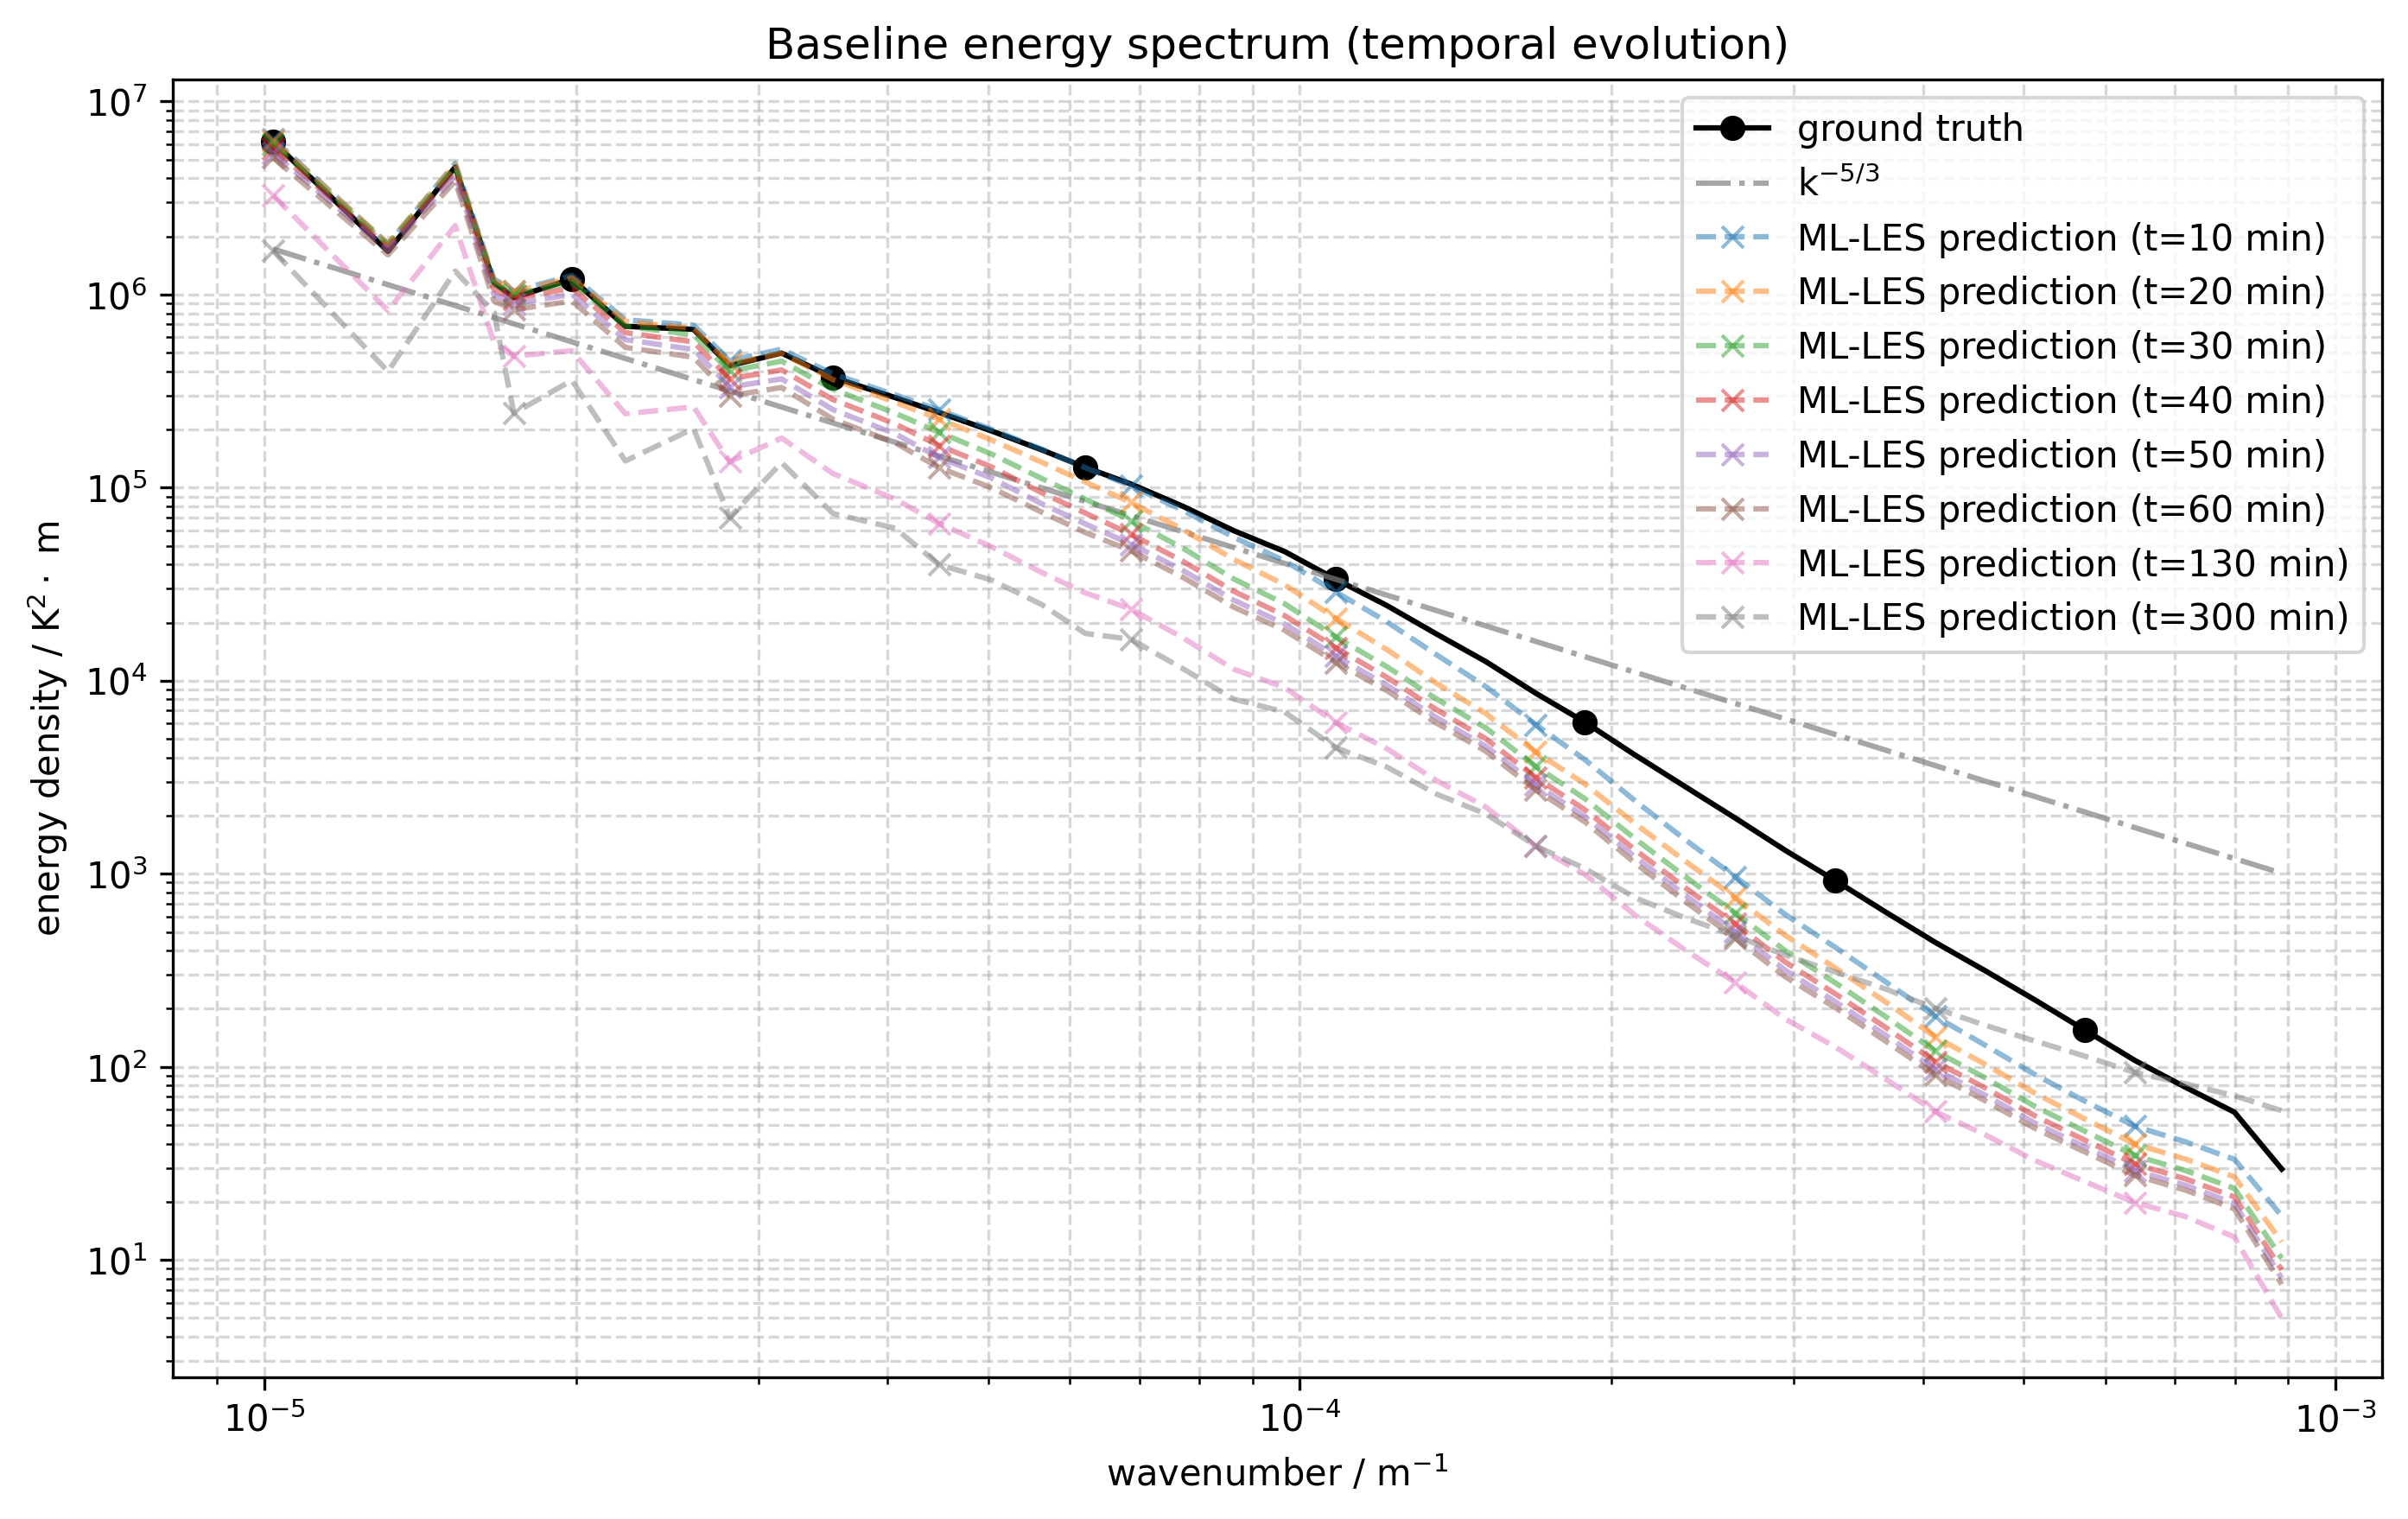

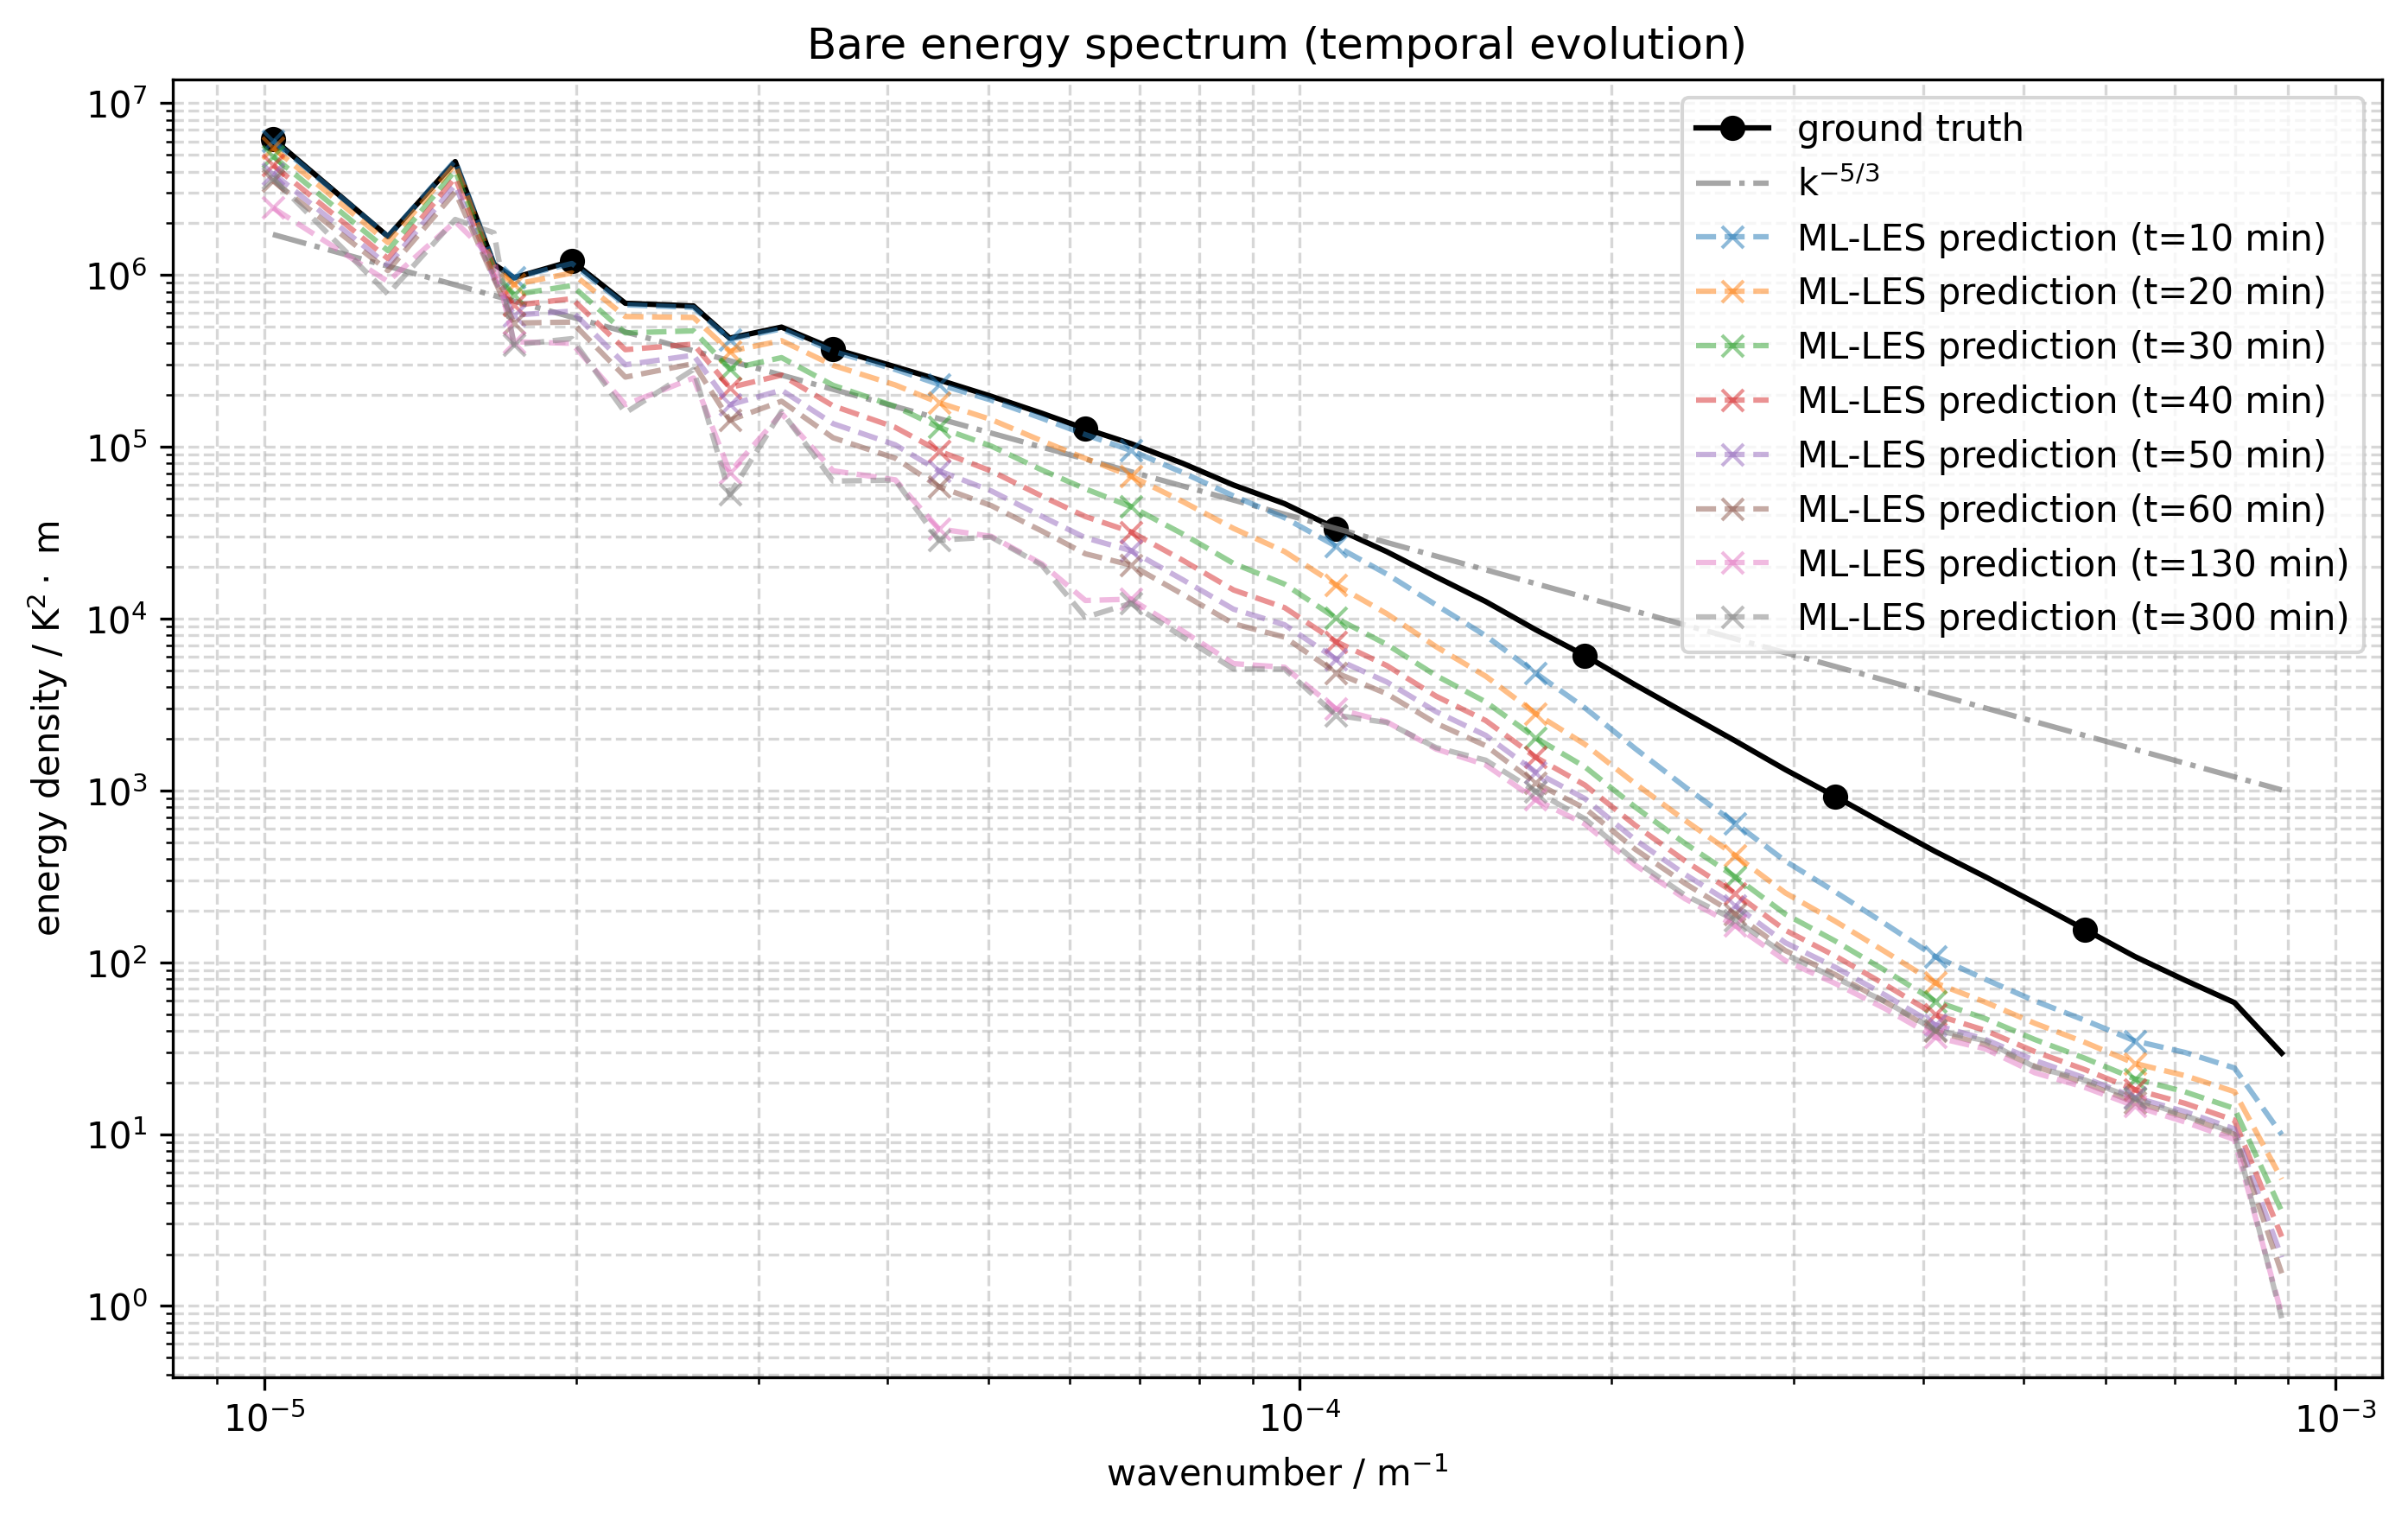

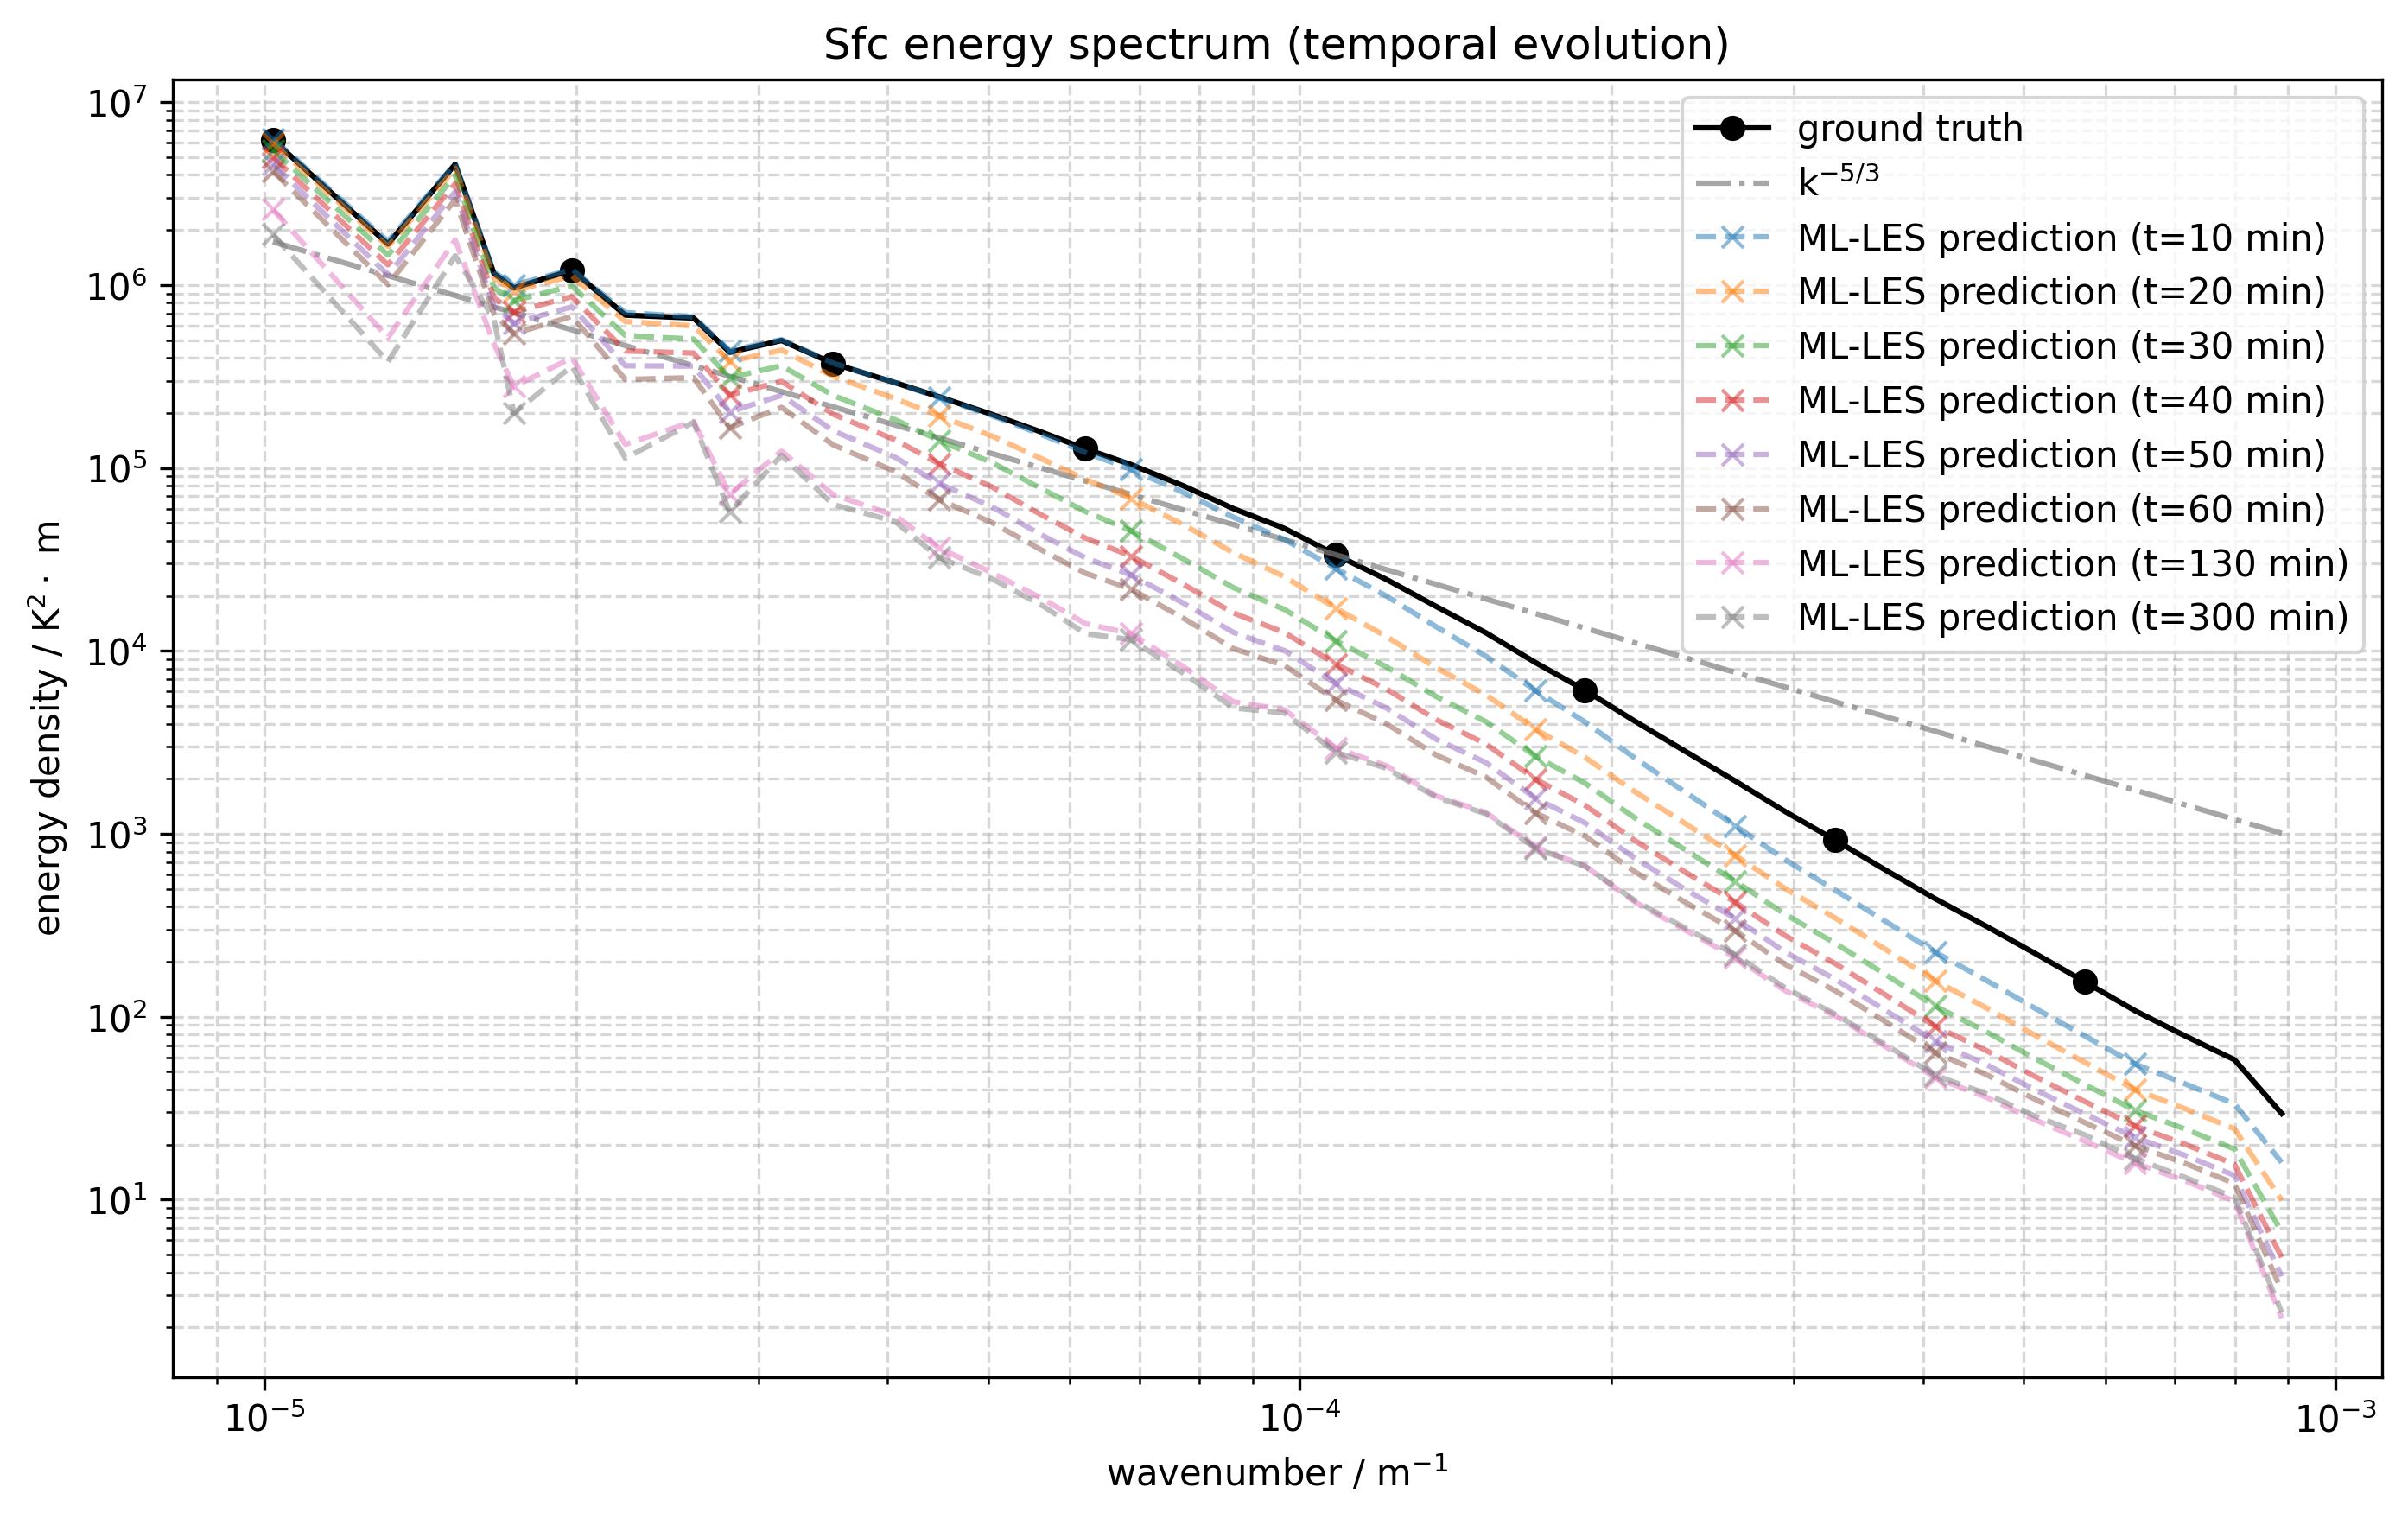

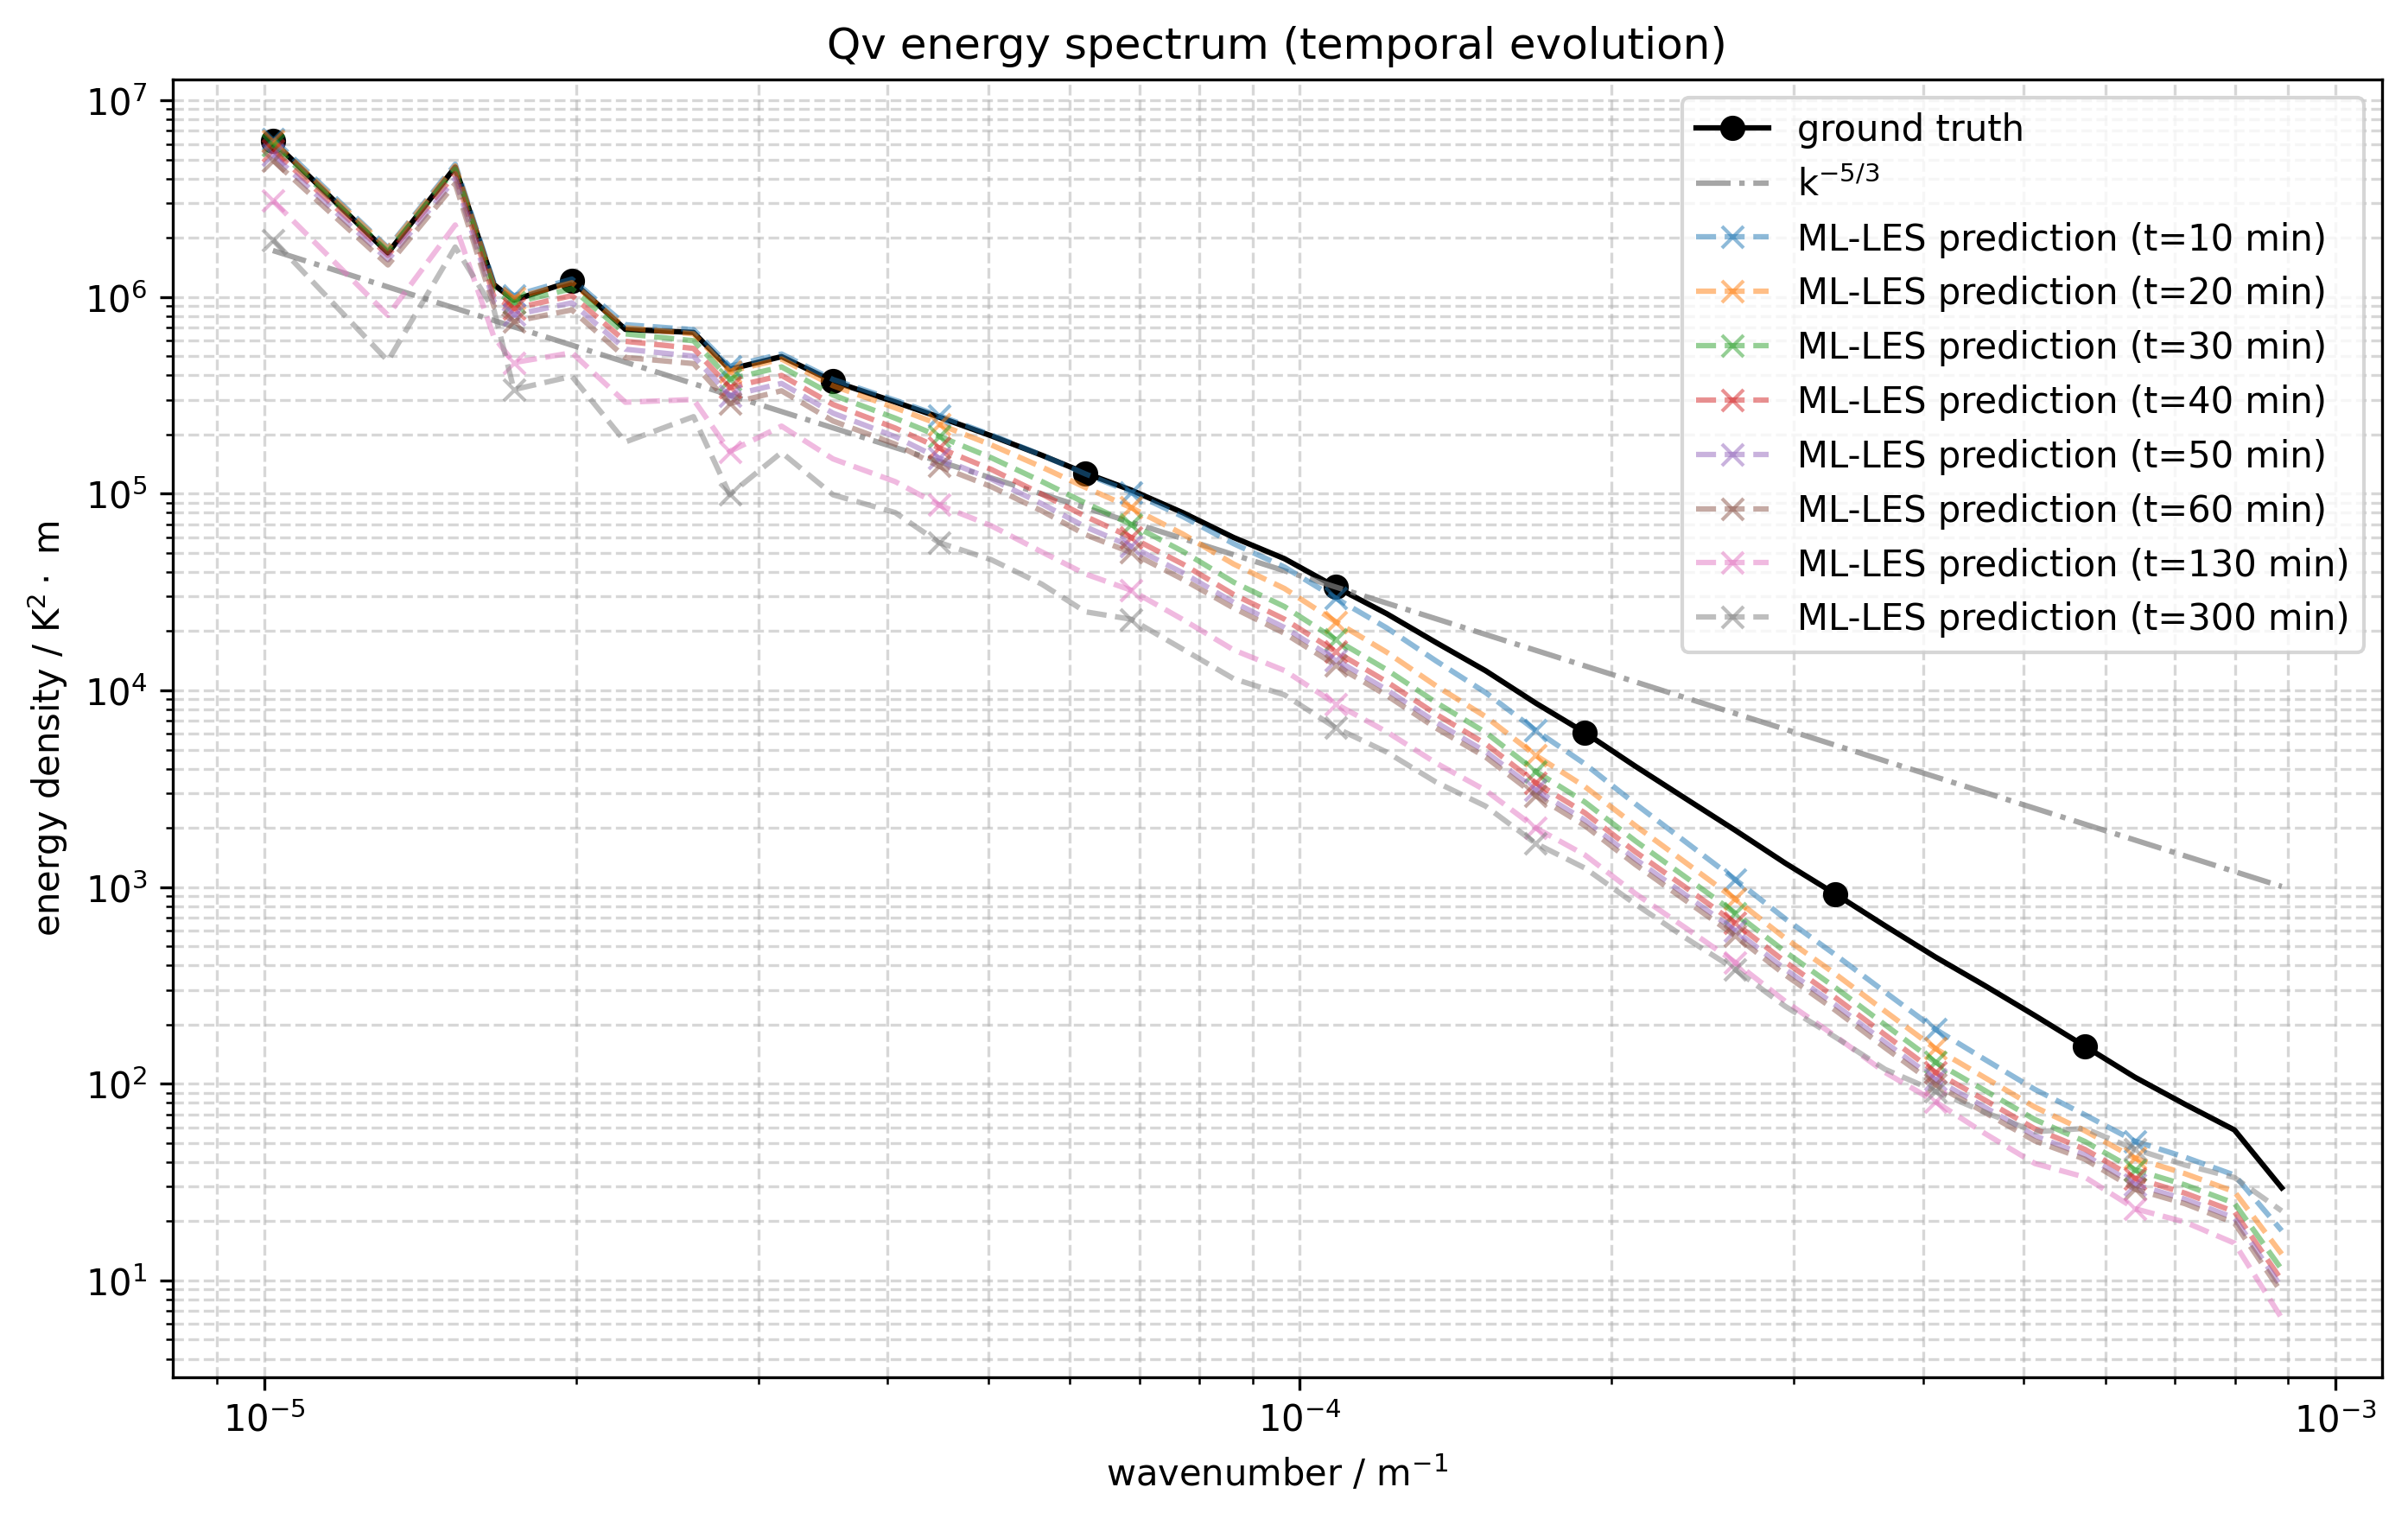

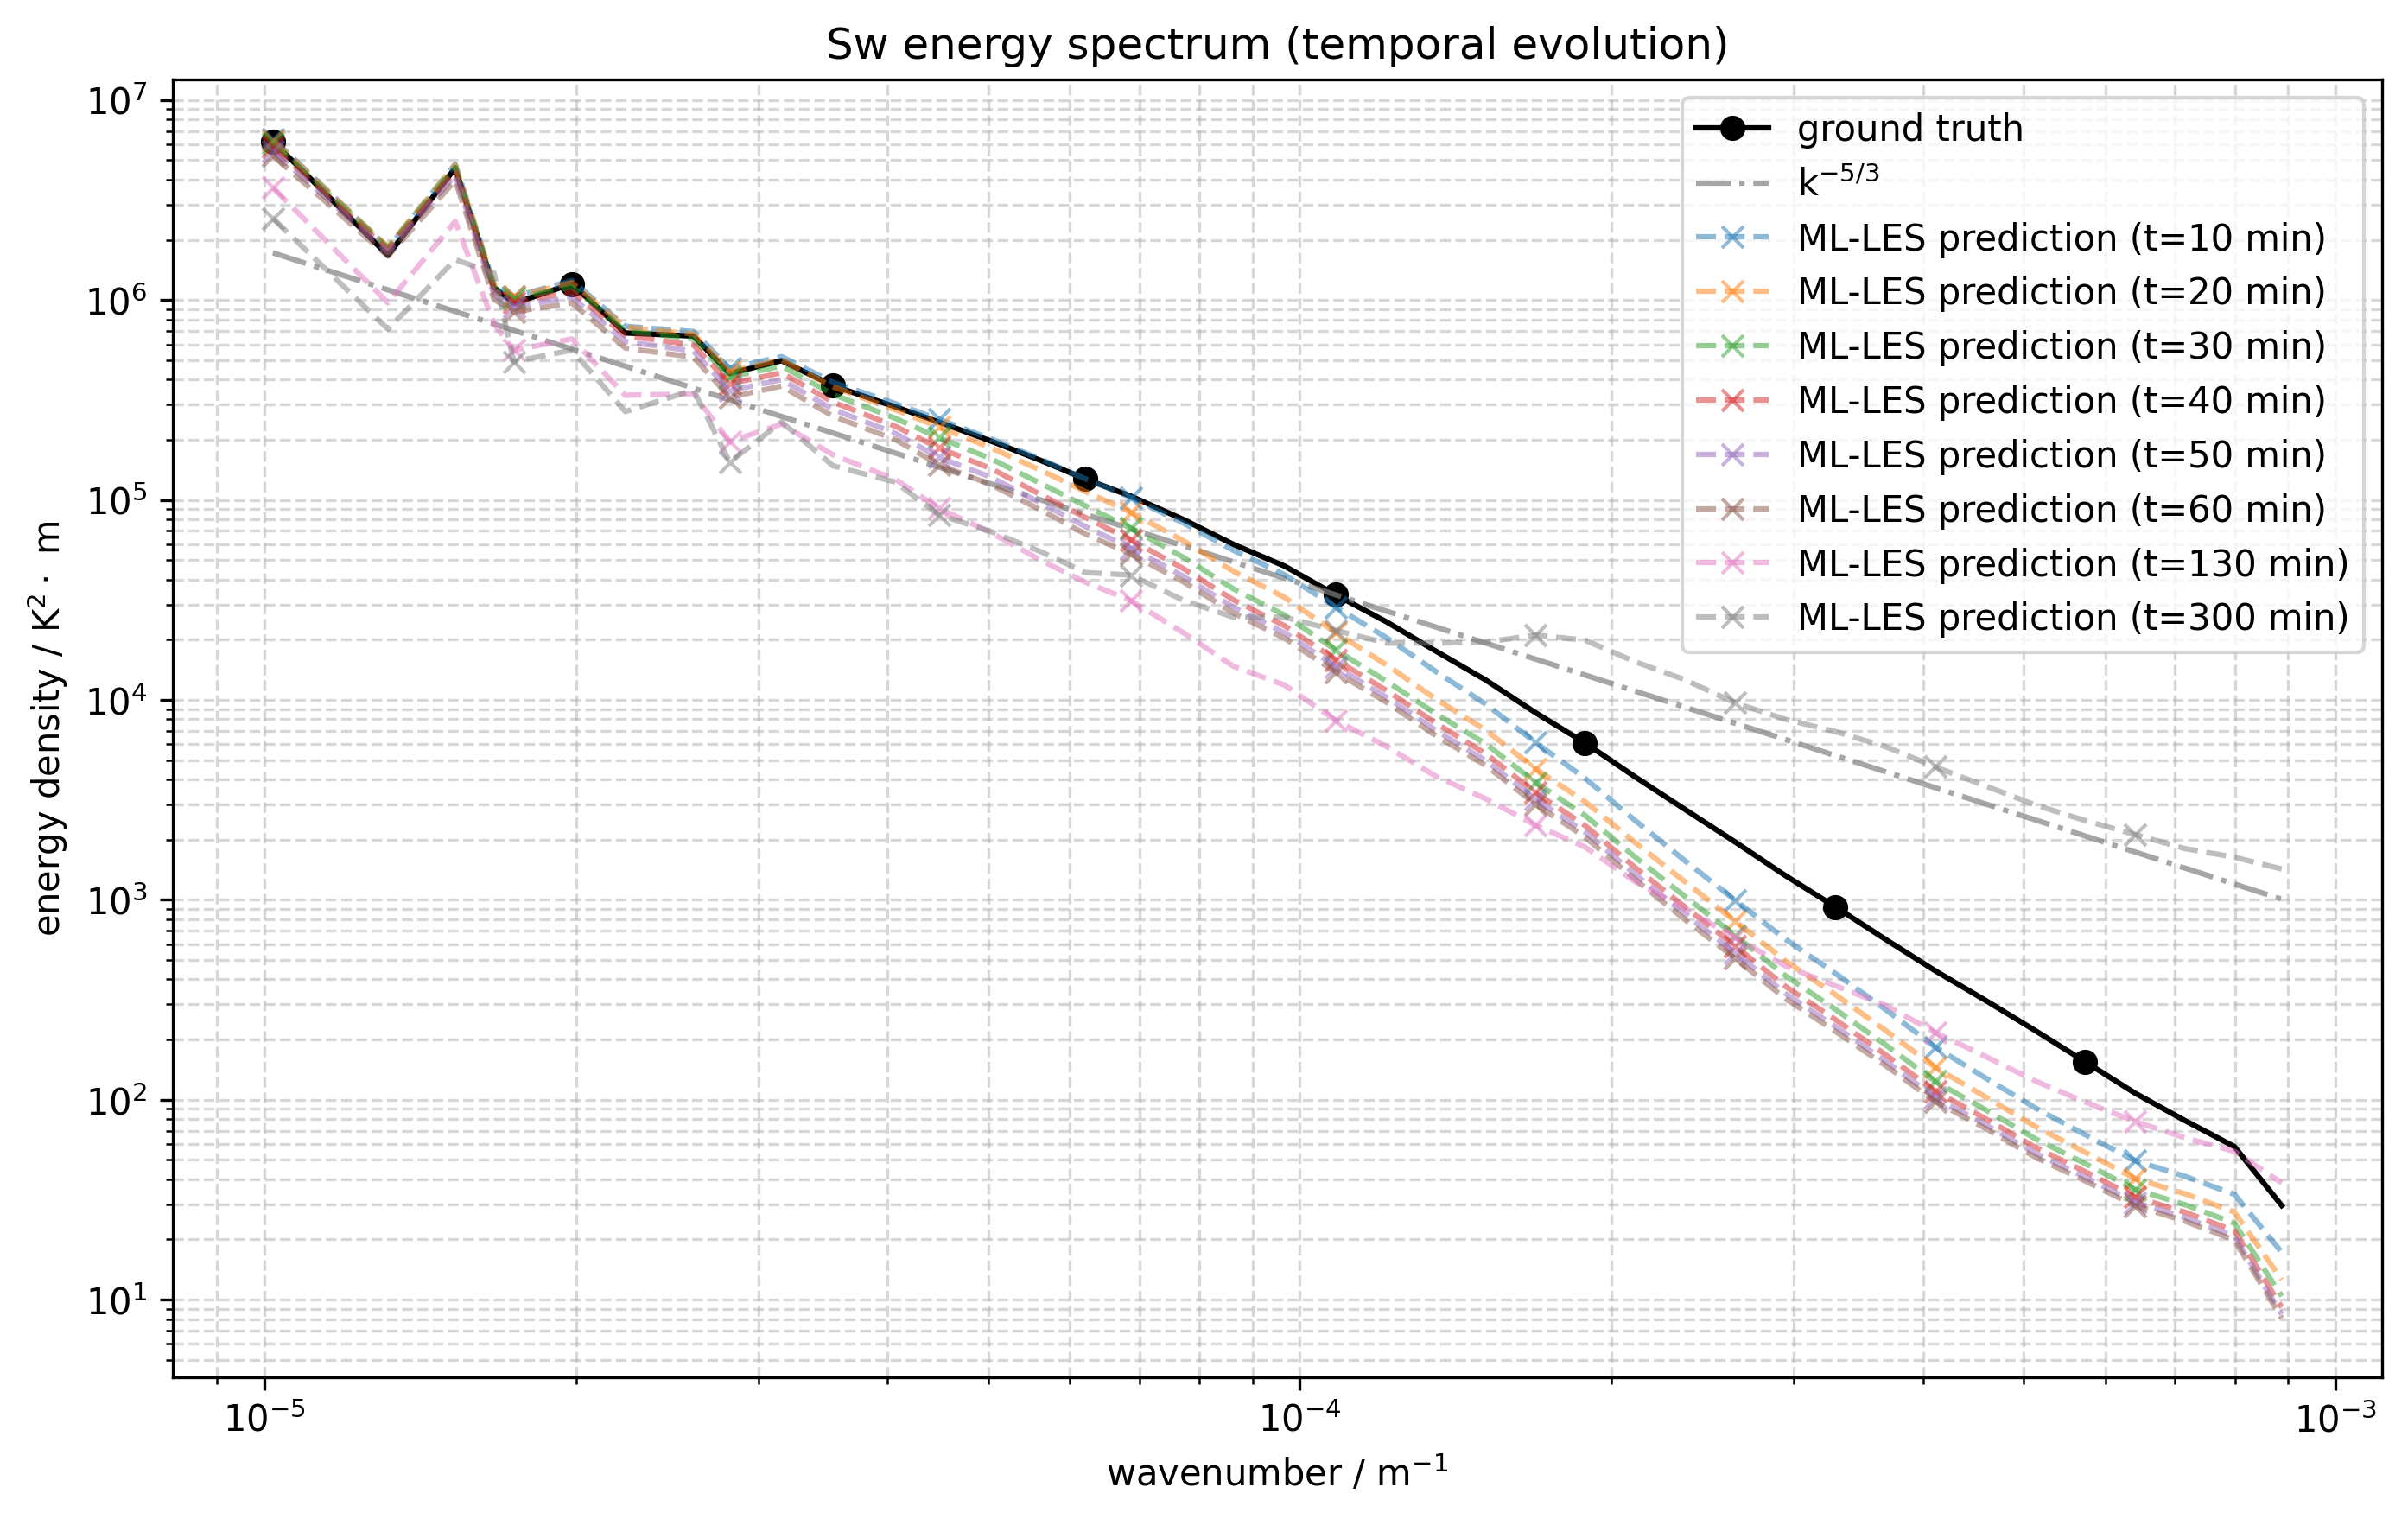

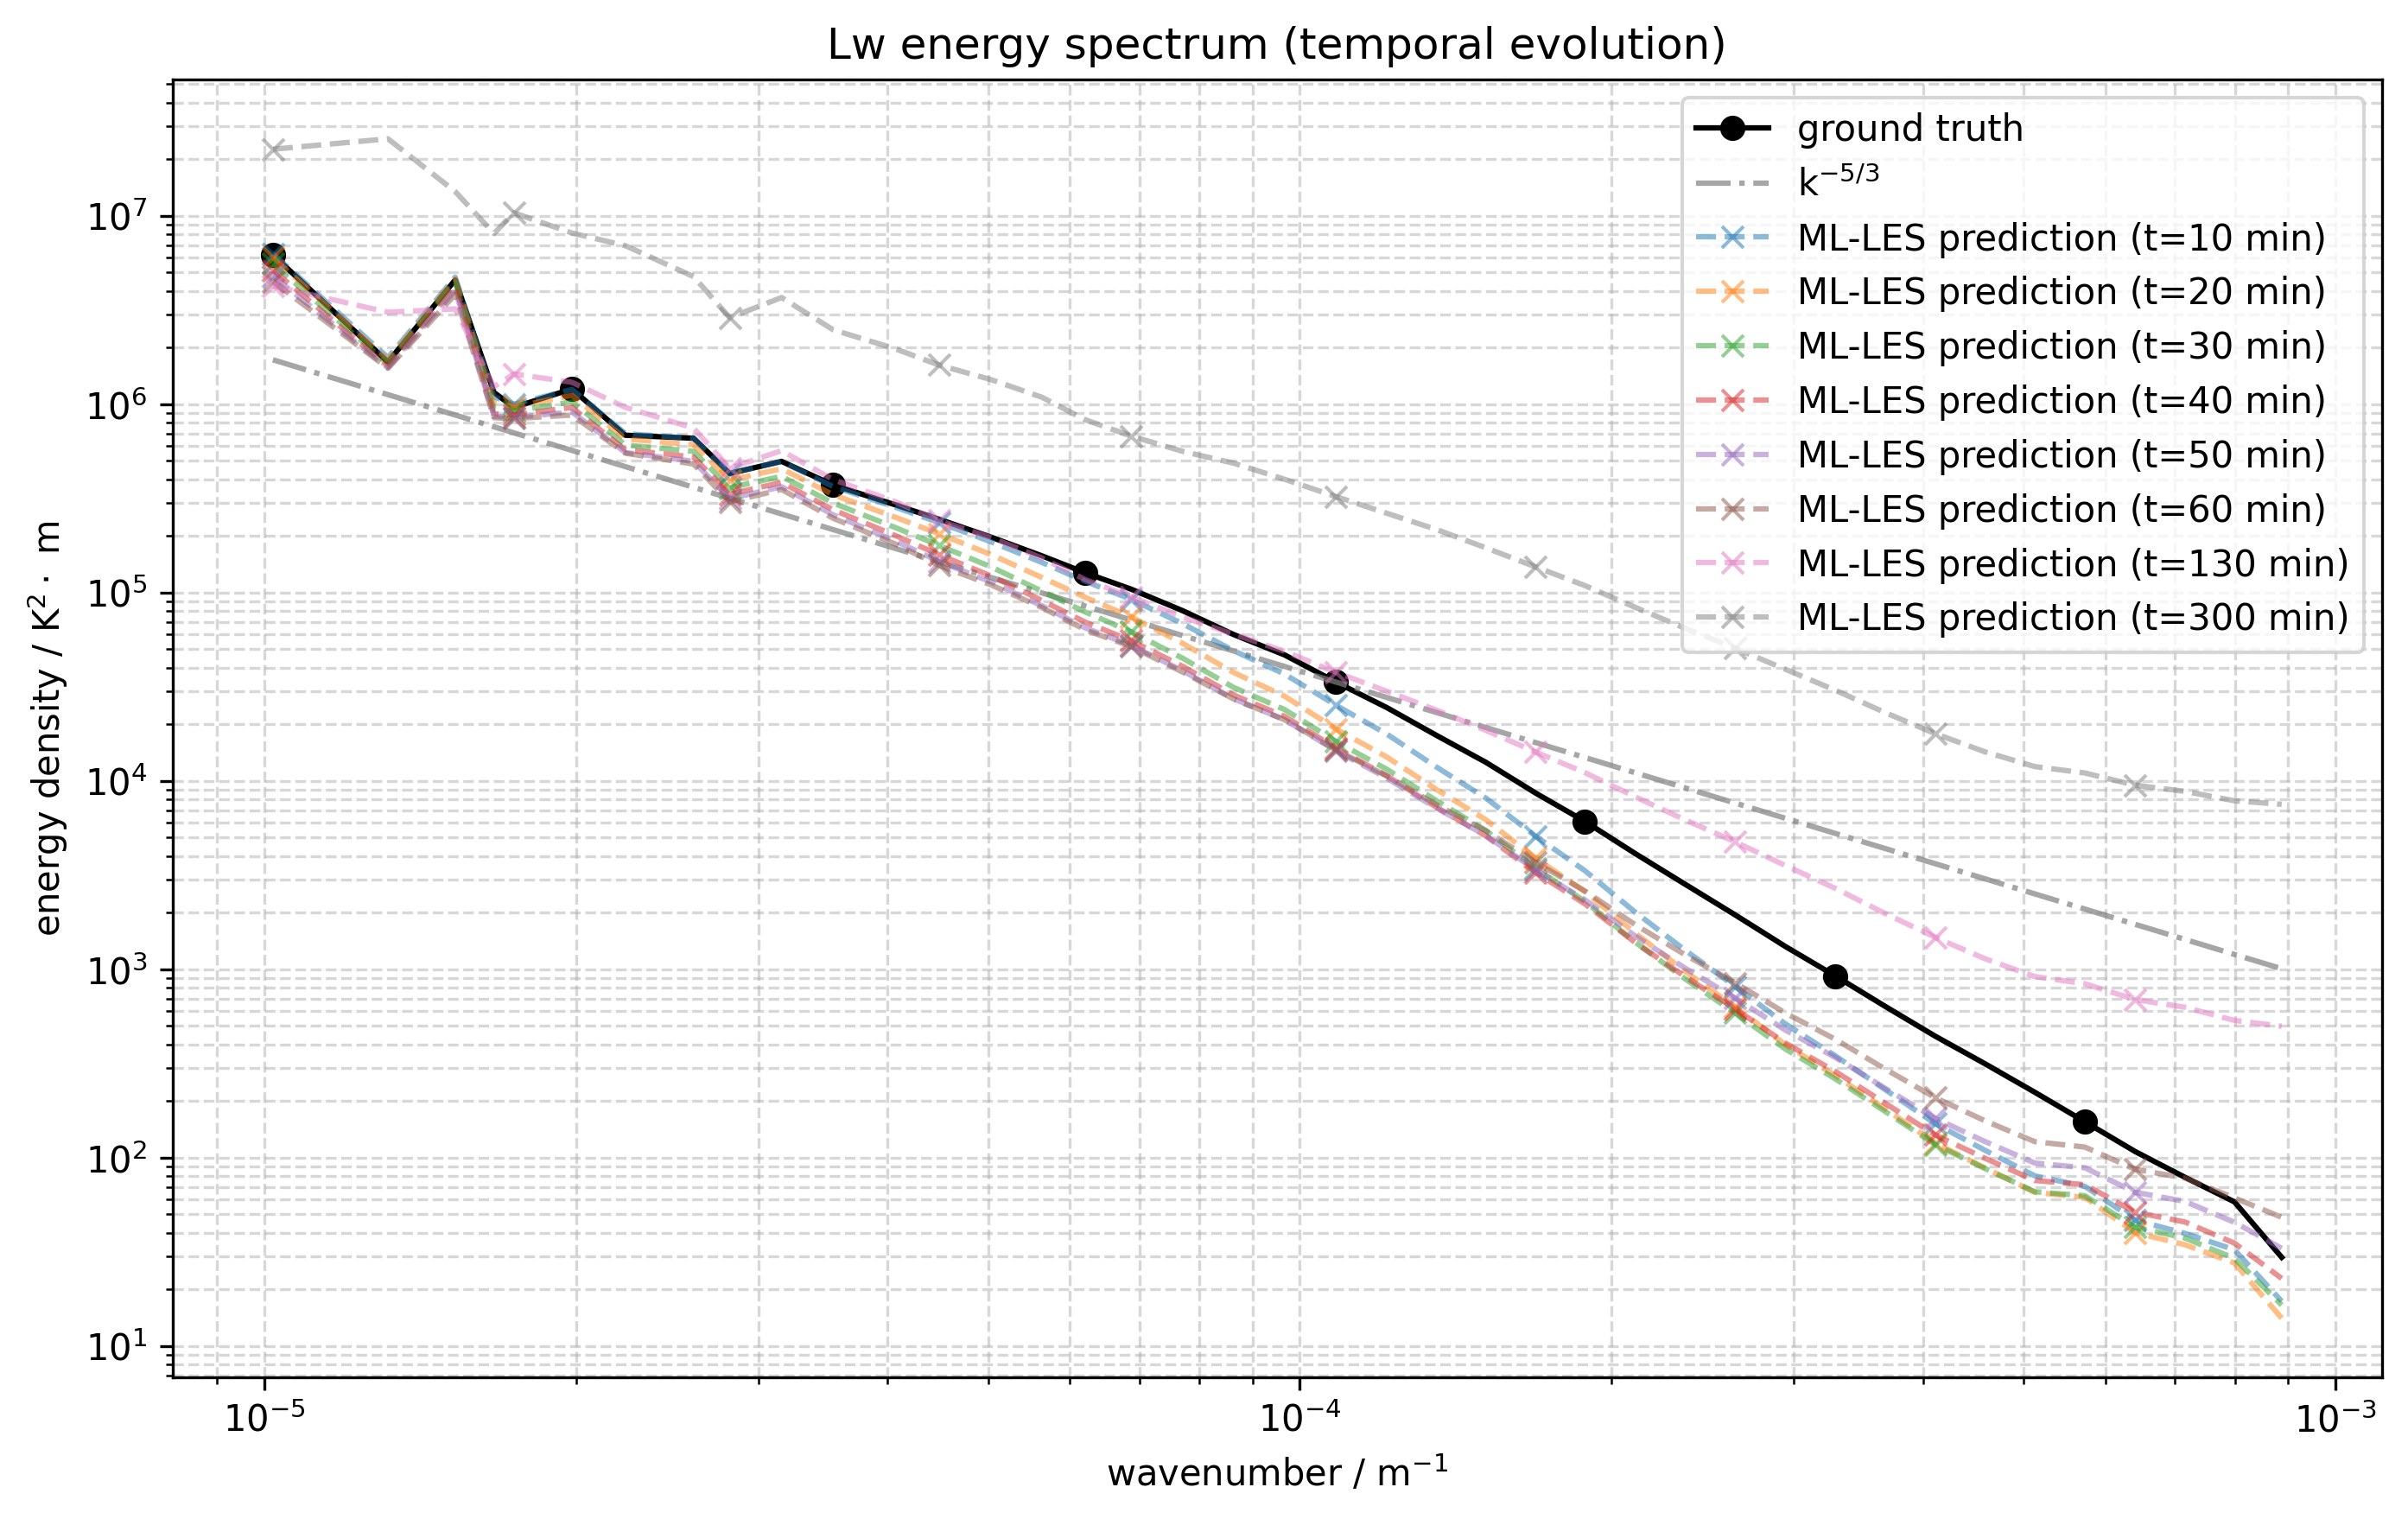

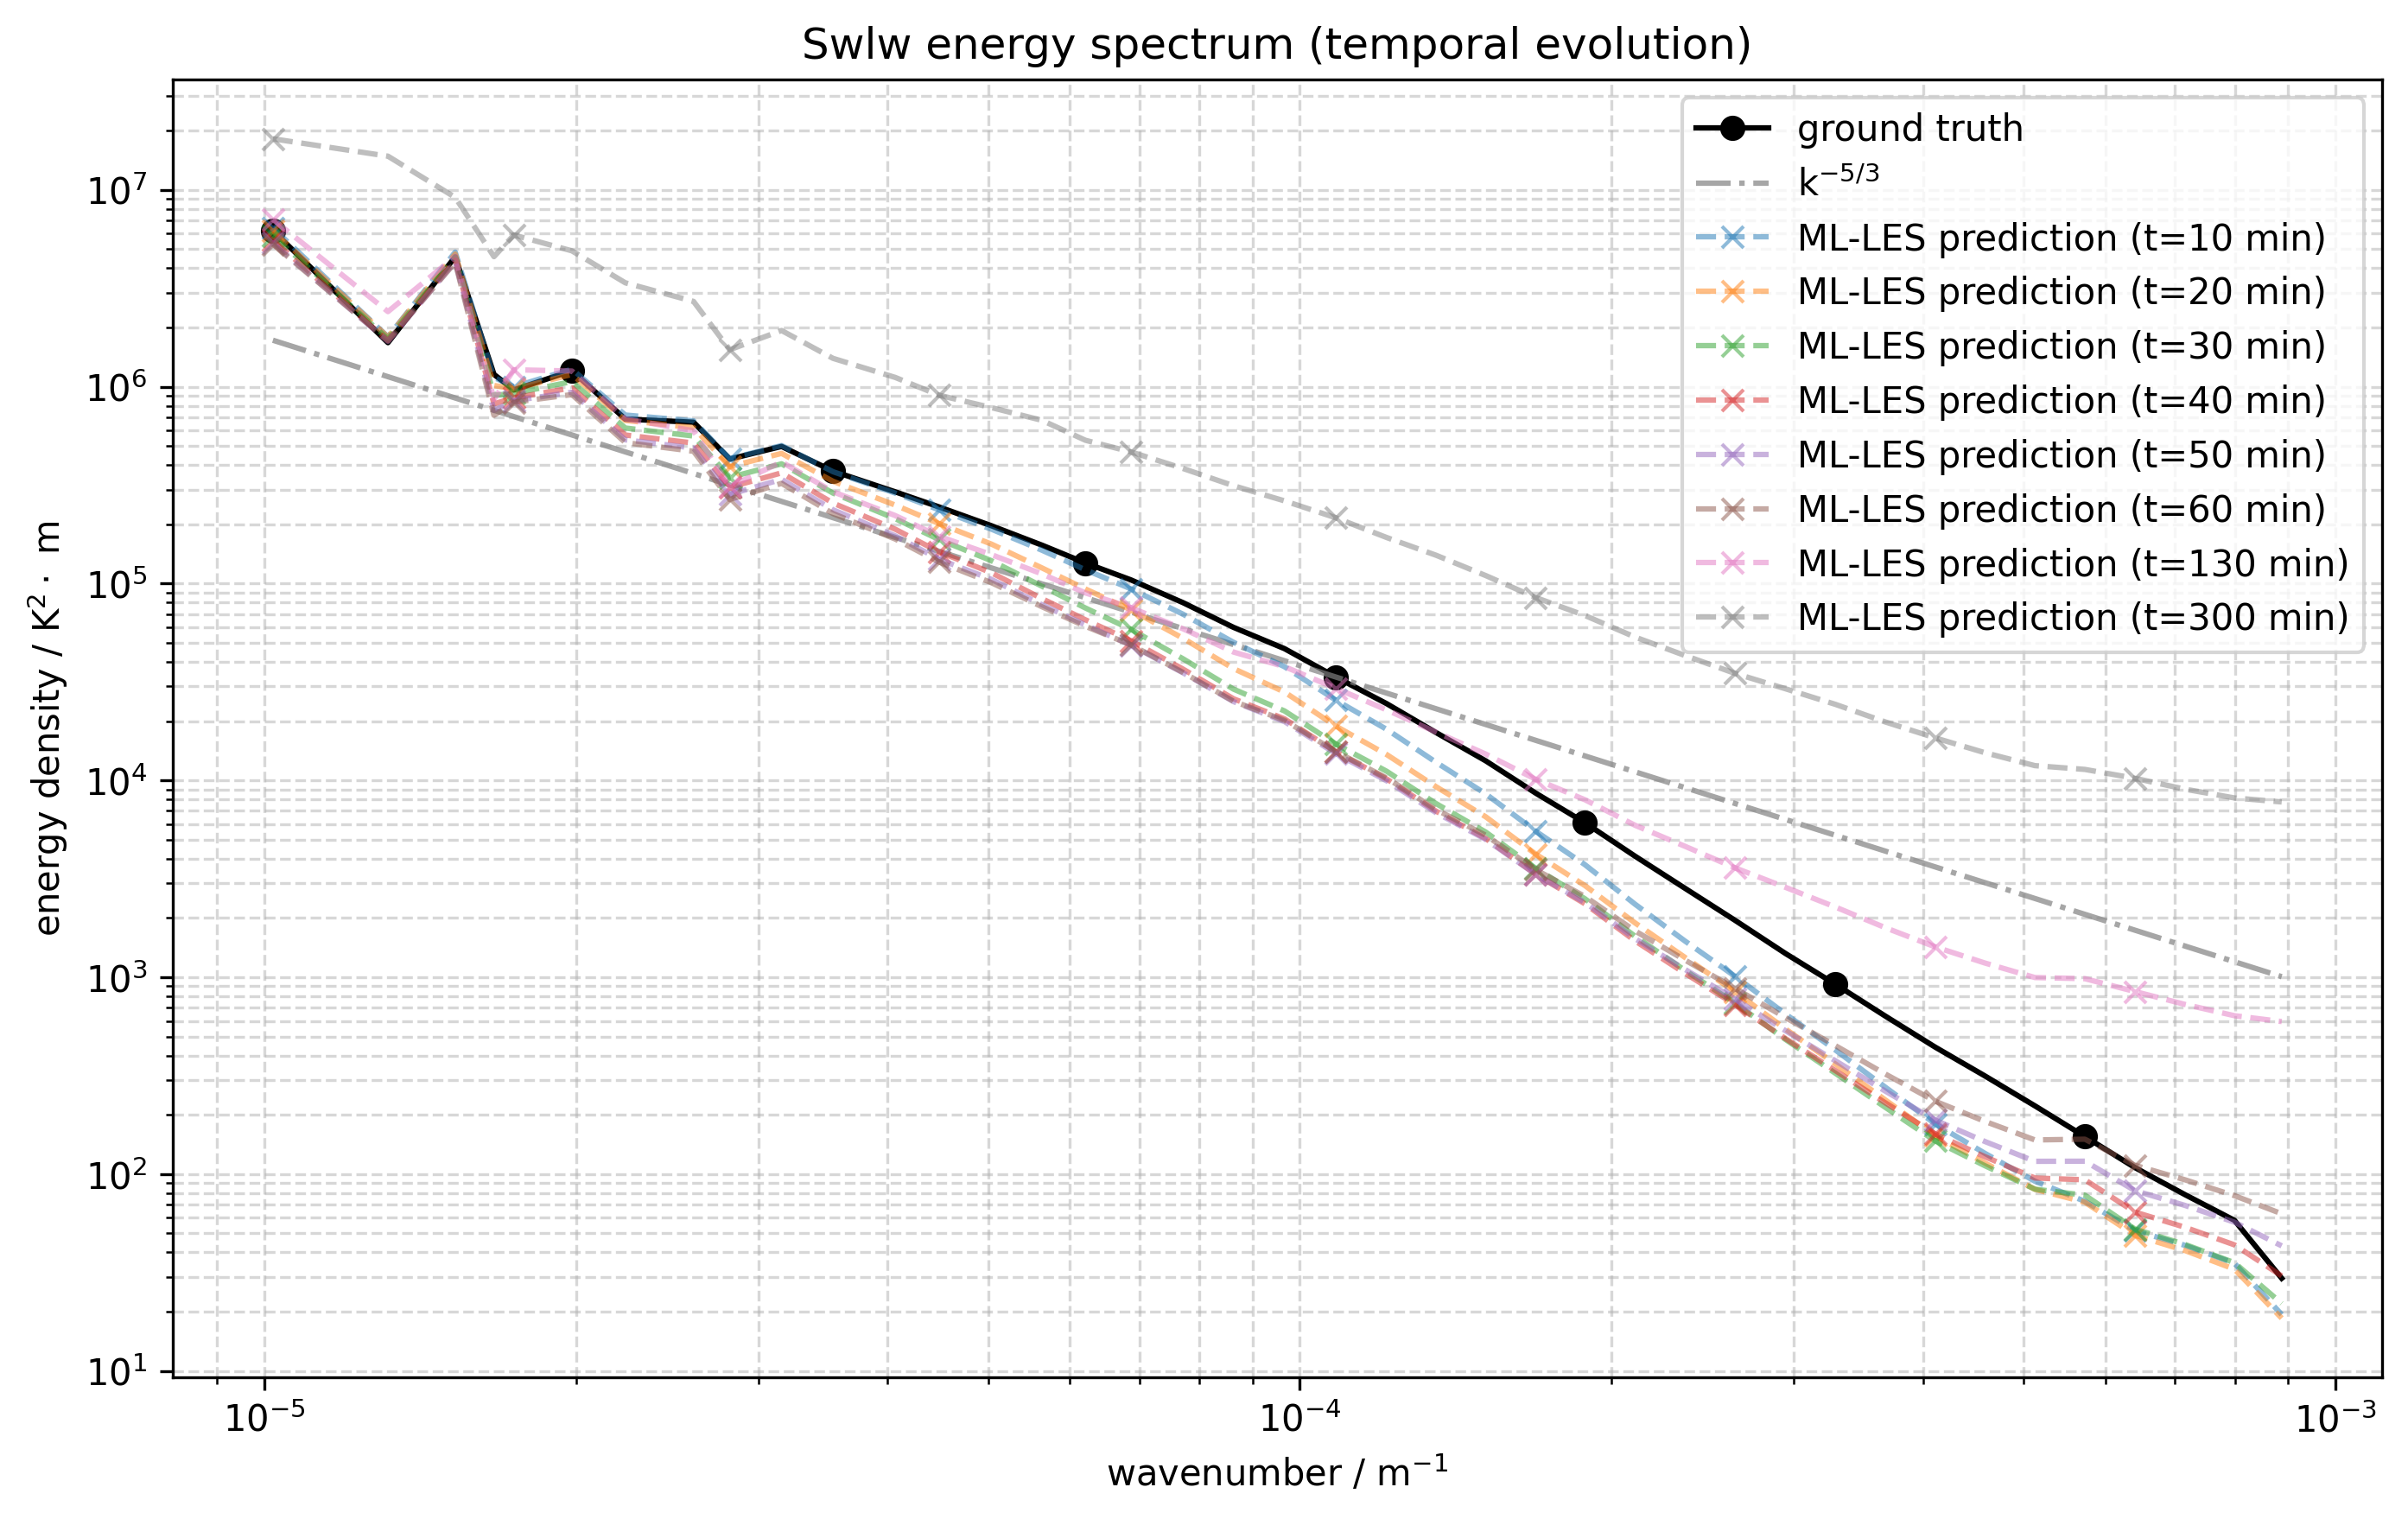

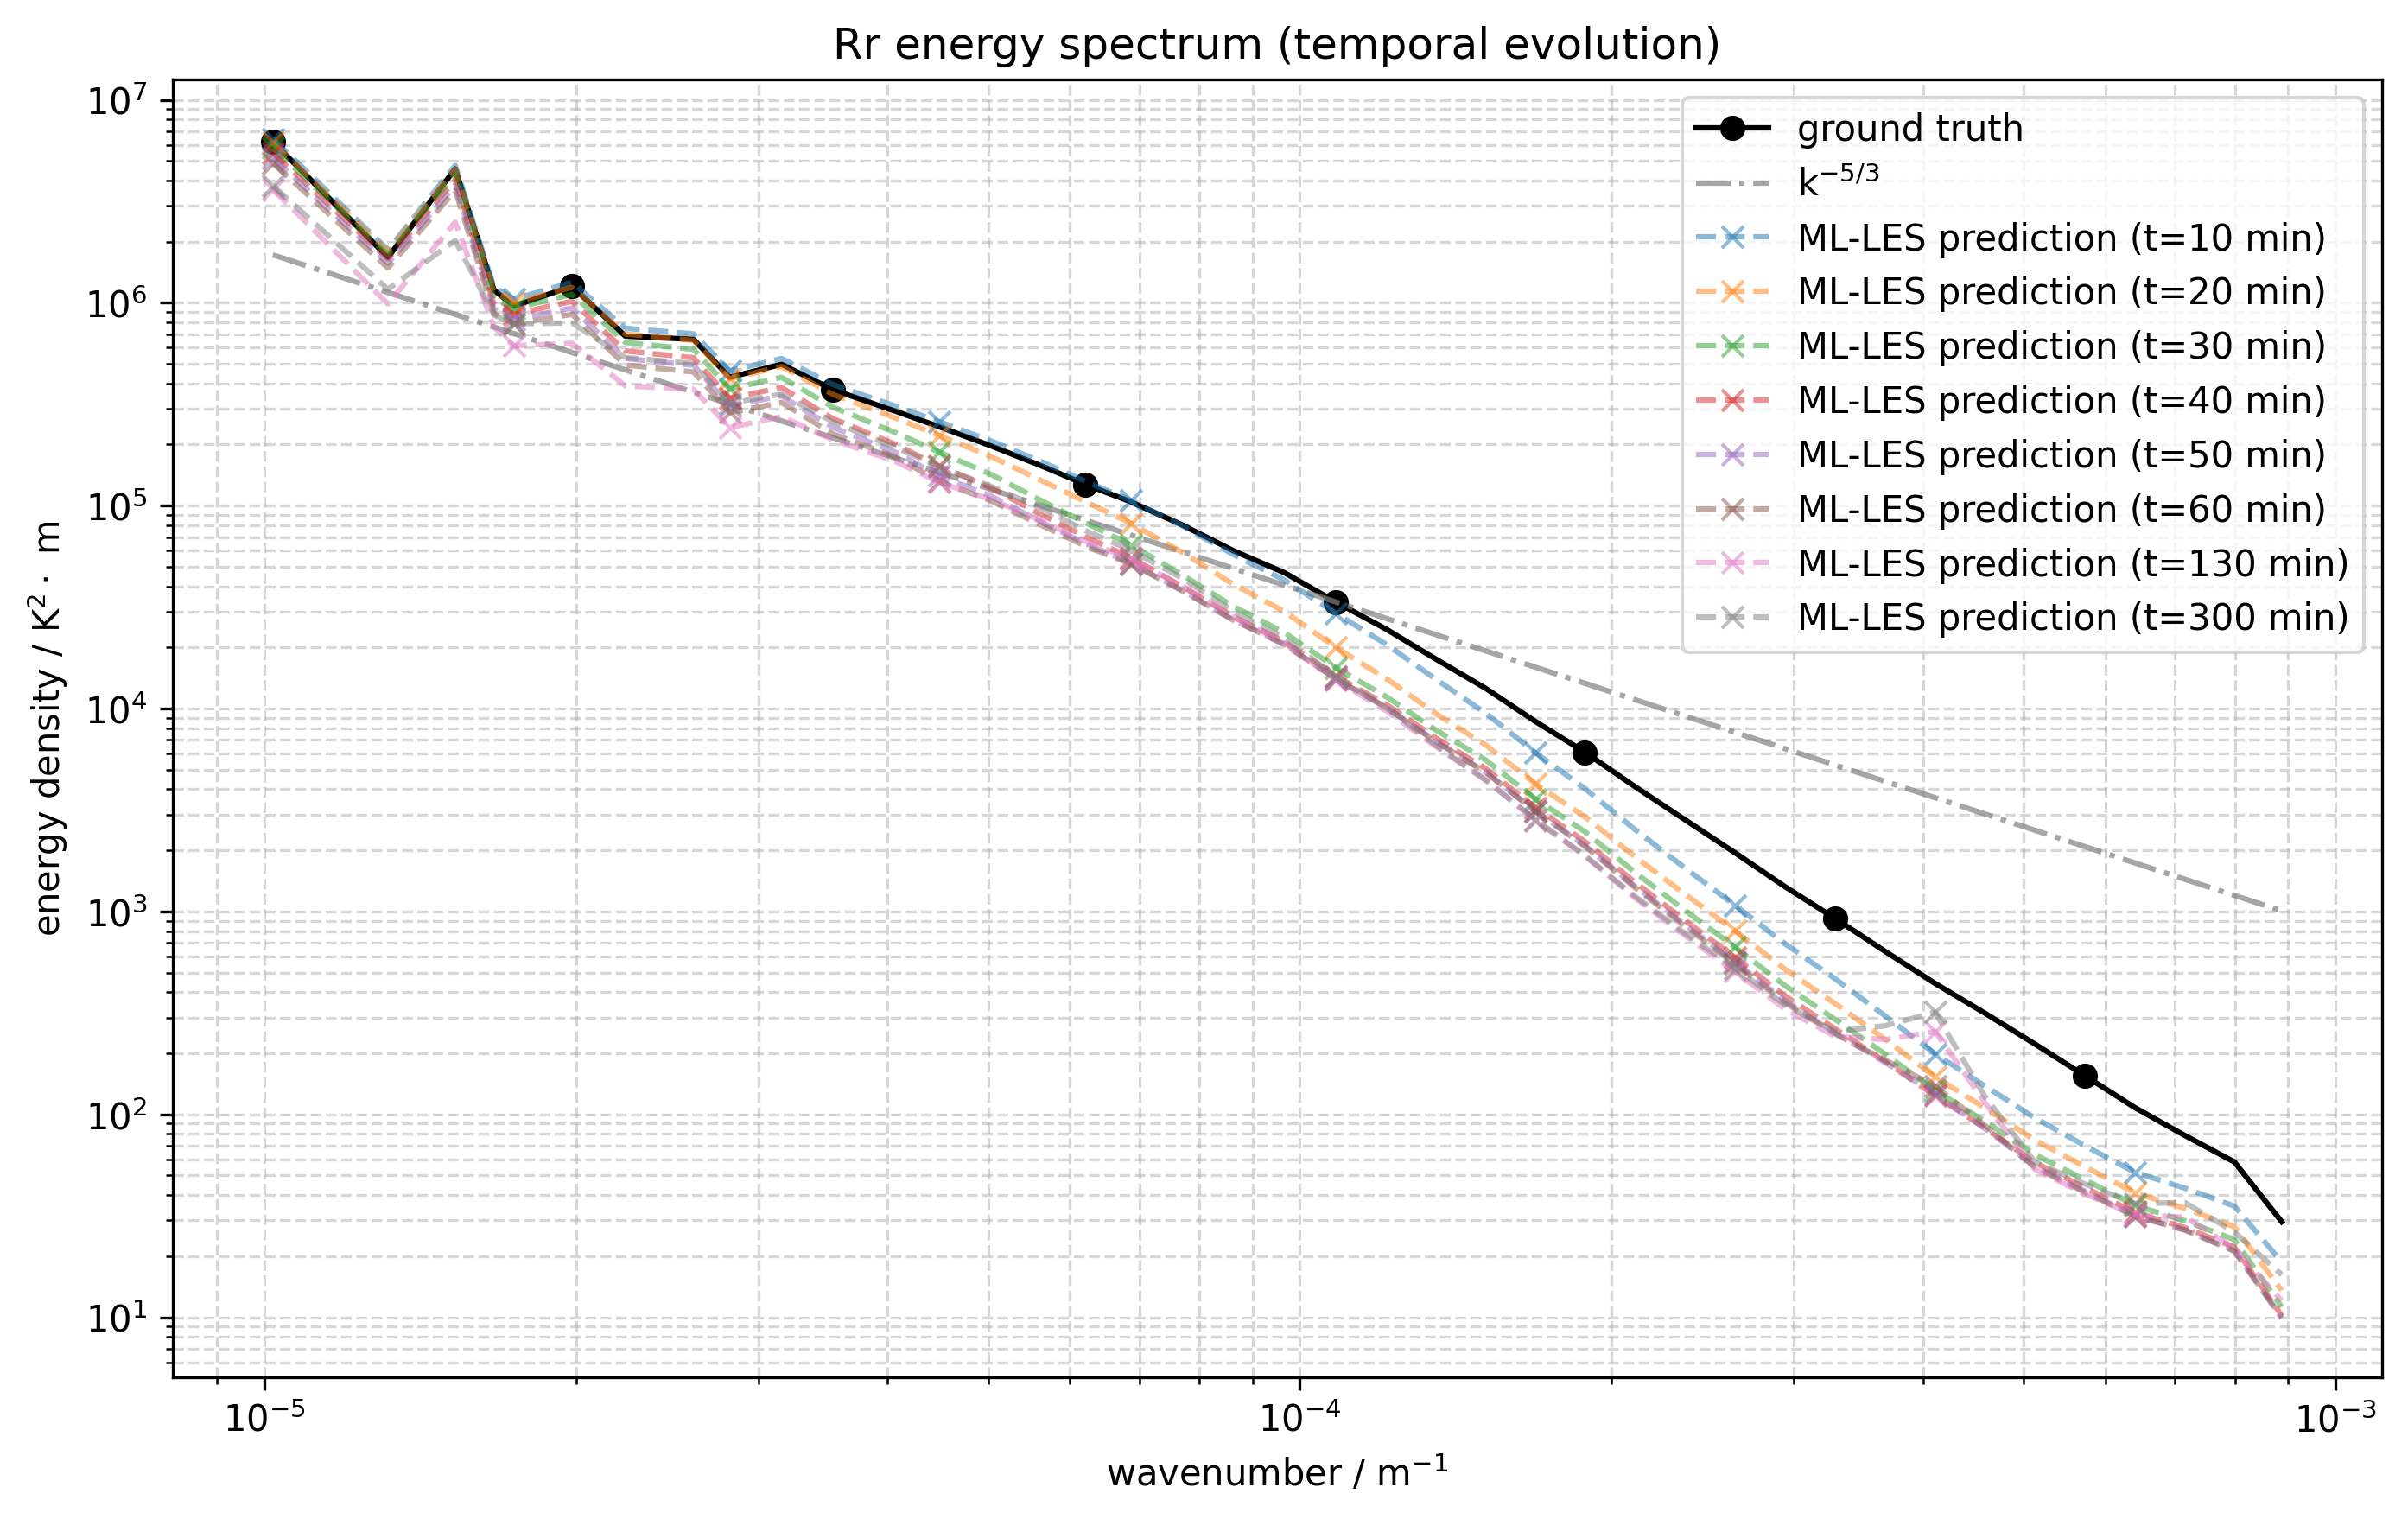

In [5]:
for name in caches:
    fig, ax = es.plot_energy_spectra(
        caches[name],
        "t_2m",
        temporal=True,
        show_legend=True,
        add_eff_res=False,
        add_lsd=False,
    )
    ax.set_title(f"{name.capitalize()} energy spectrum (temporal evolution)");

In [6]:
for name in ["baseline", "bare", "sfc", "qv", "sw", "lw", "swlw", "rr"]:
    caches[name] = restrict_to_time(caches[name])

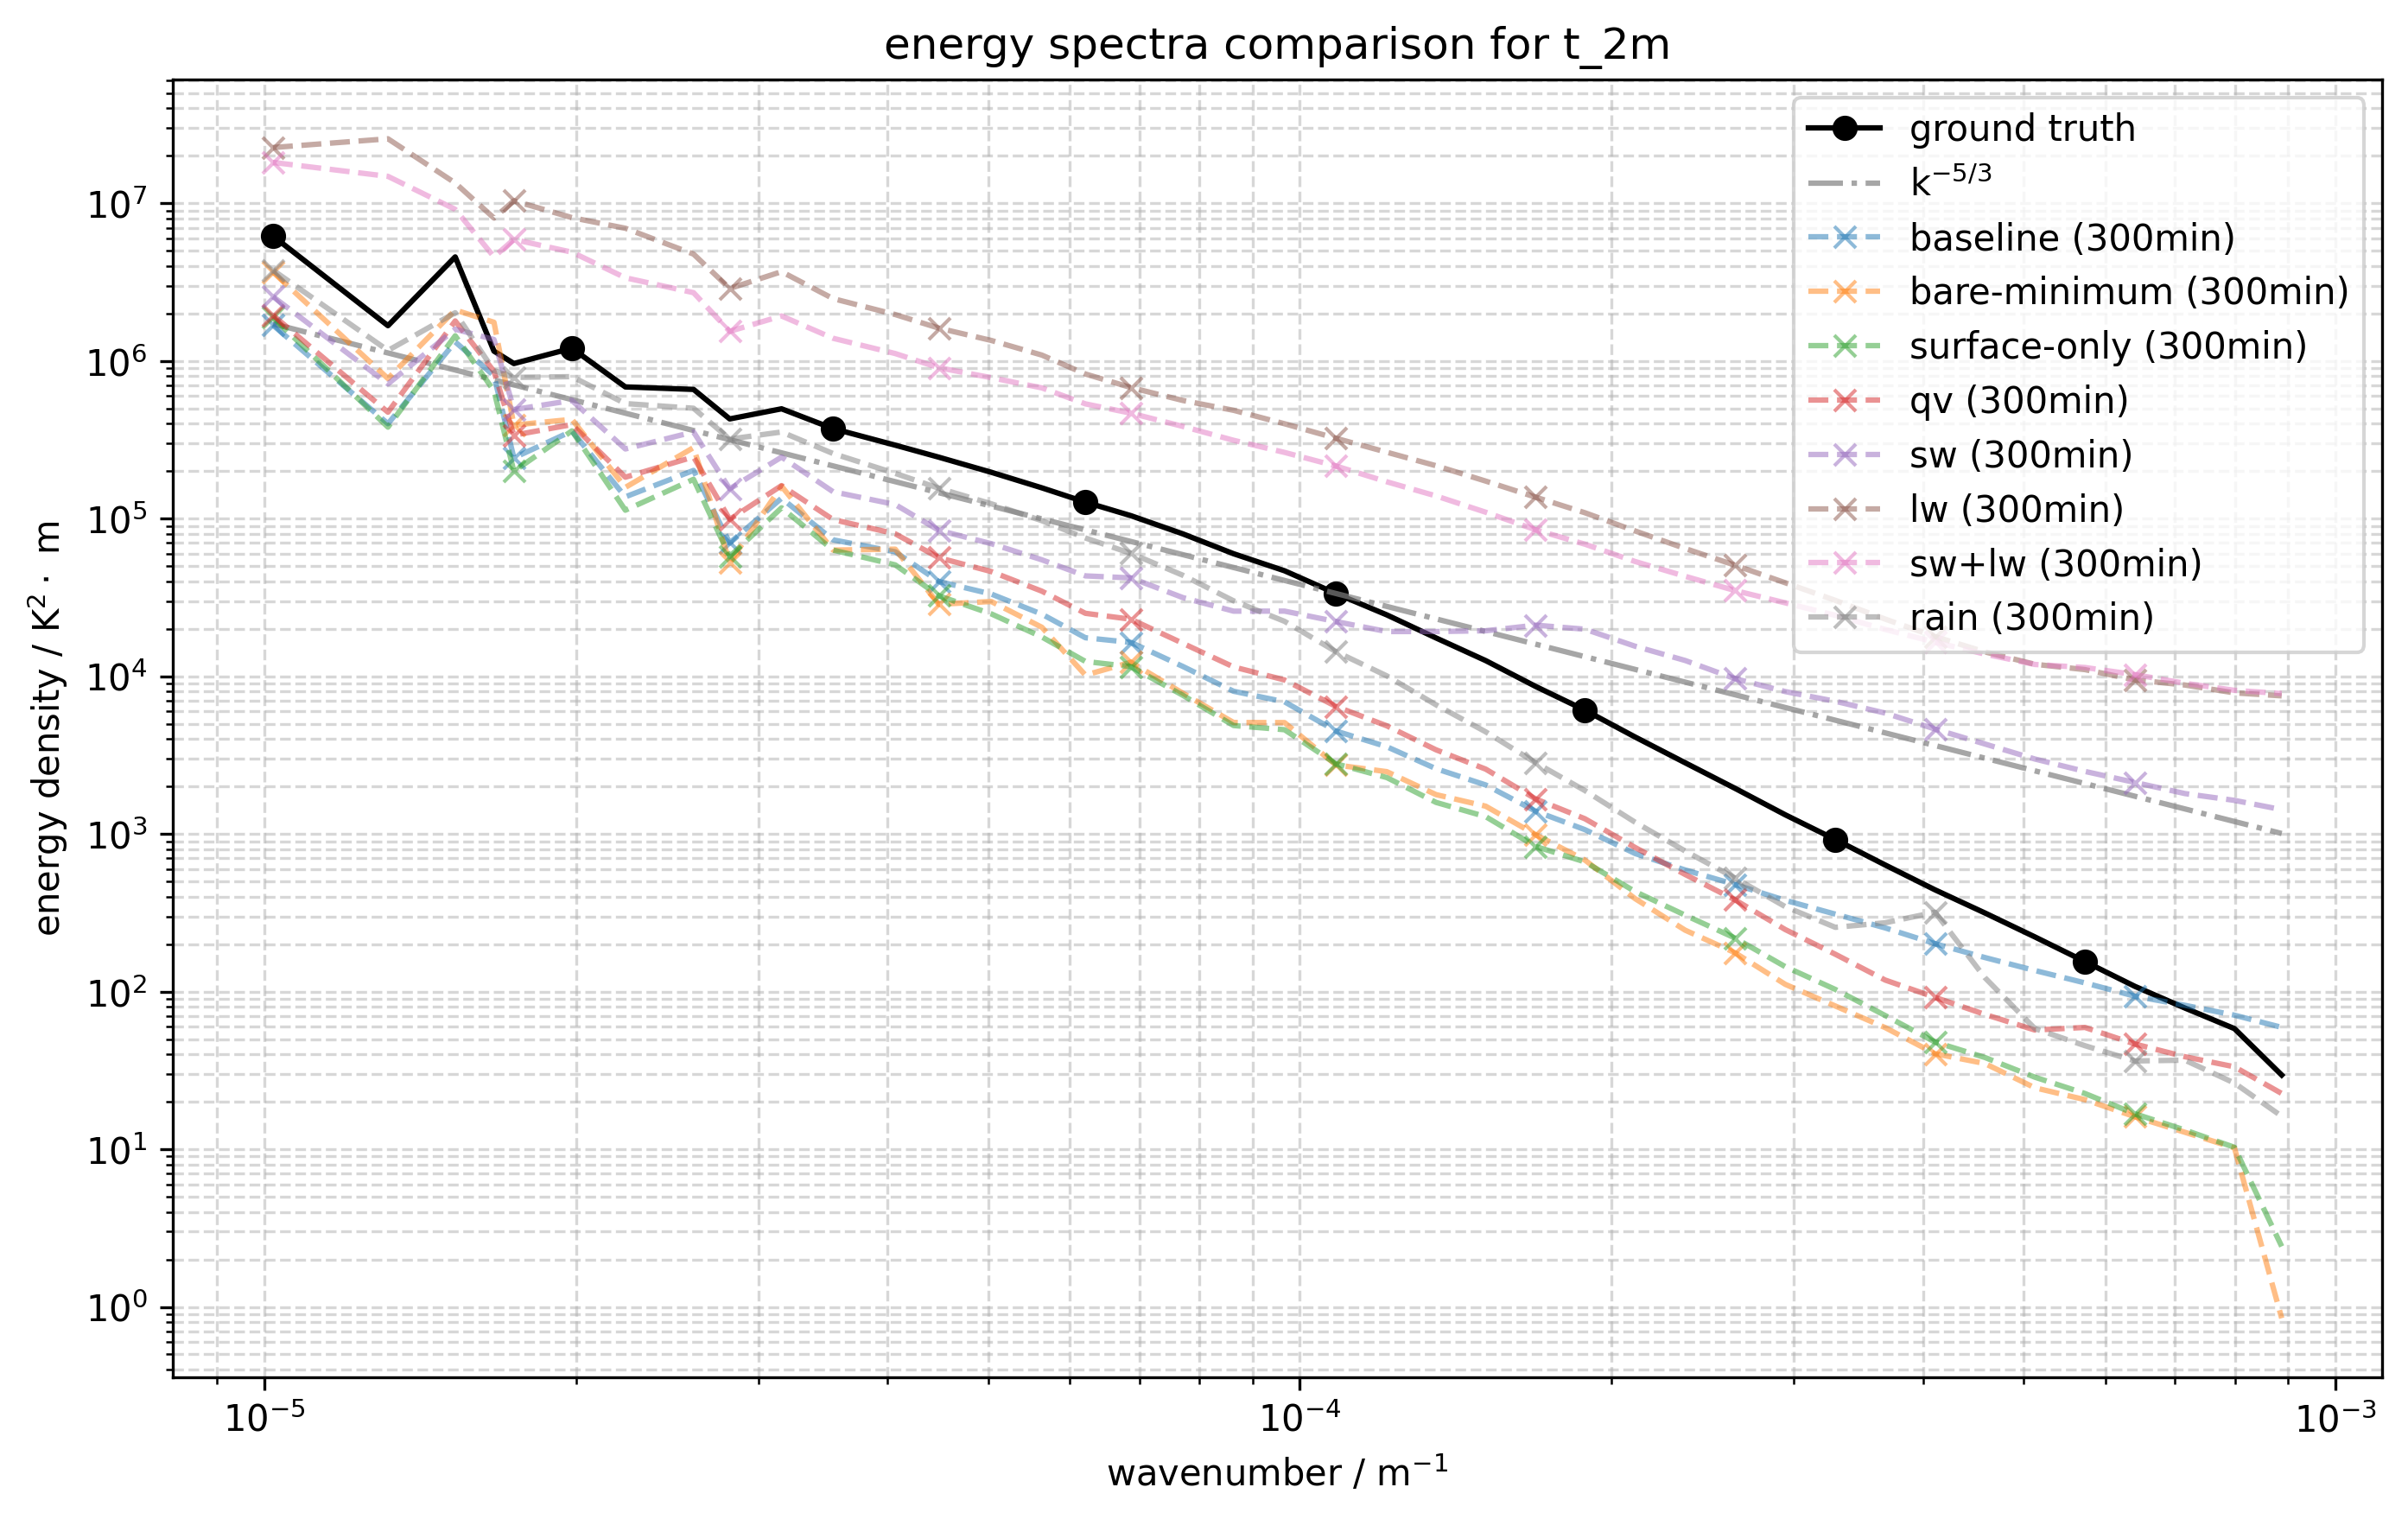

In [7]:
# loop over the caches defined above instead of repeating calls manually
fig = None
ax = None
for name, label in labels.items():
    kwargs = dict(show_legend=True, temporal=True, label=label,
                  add_eff_res=False, add_lsd=False)
    if ax is not None:
        kwargs["ax"] = ax
        kwargs["add_gt"] = False  # only show ground truth once

    fig, ax = es.plot_energy_spectra(caches[name], "t_2m", **kwargs)

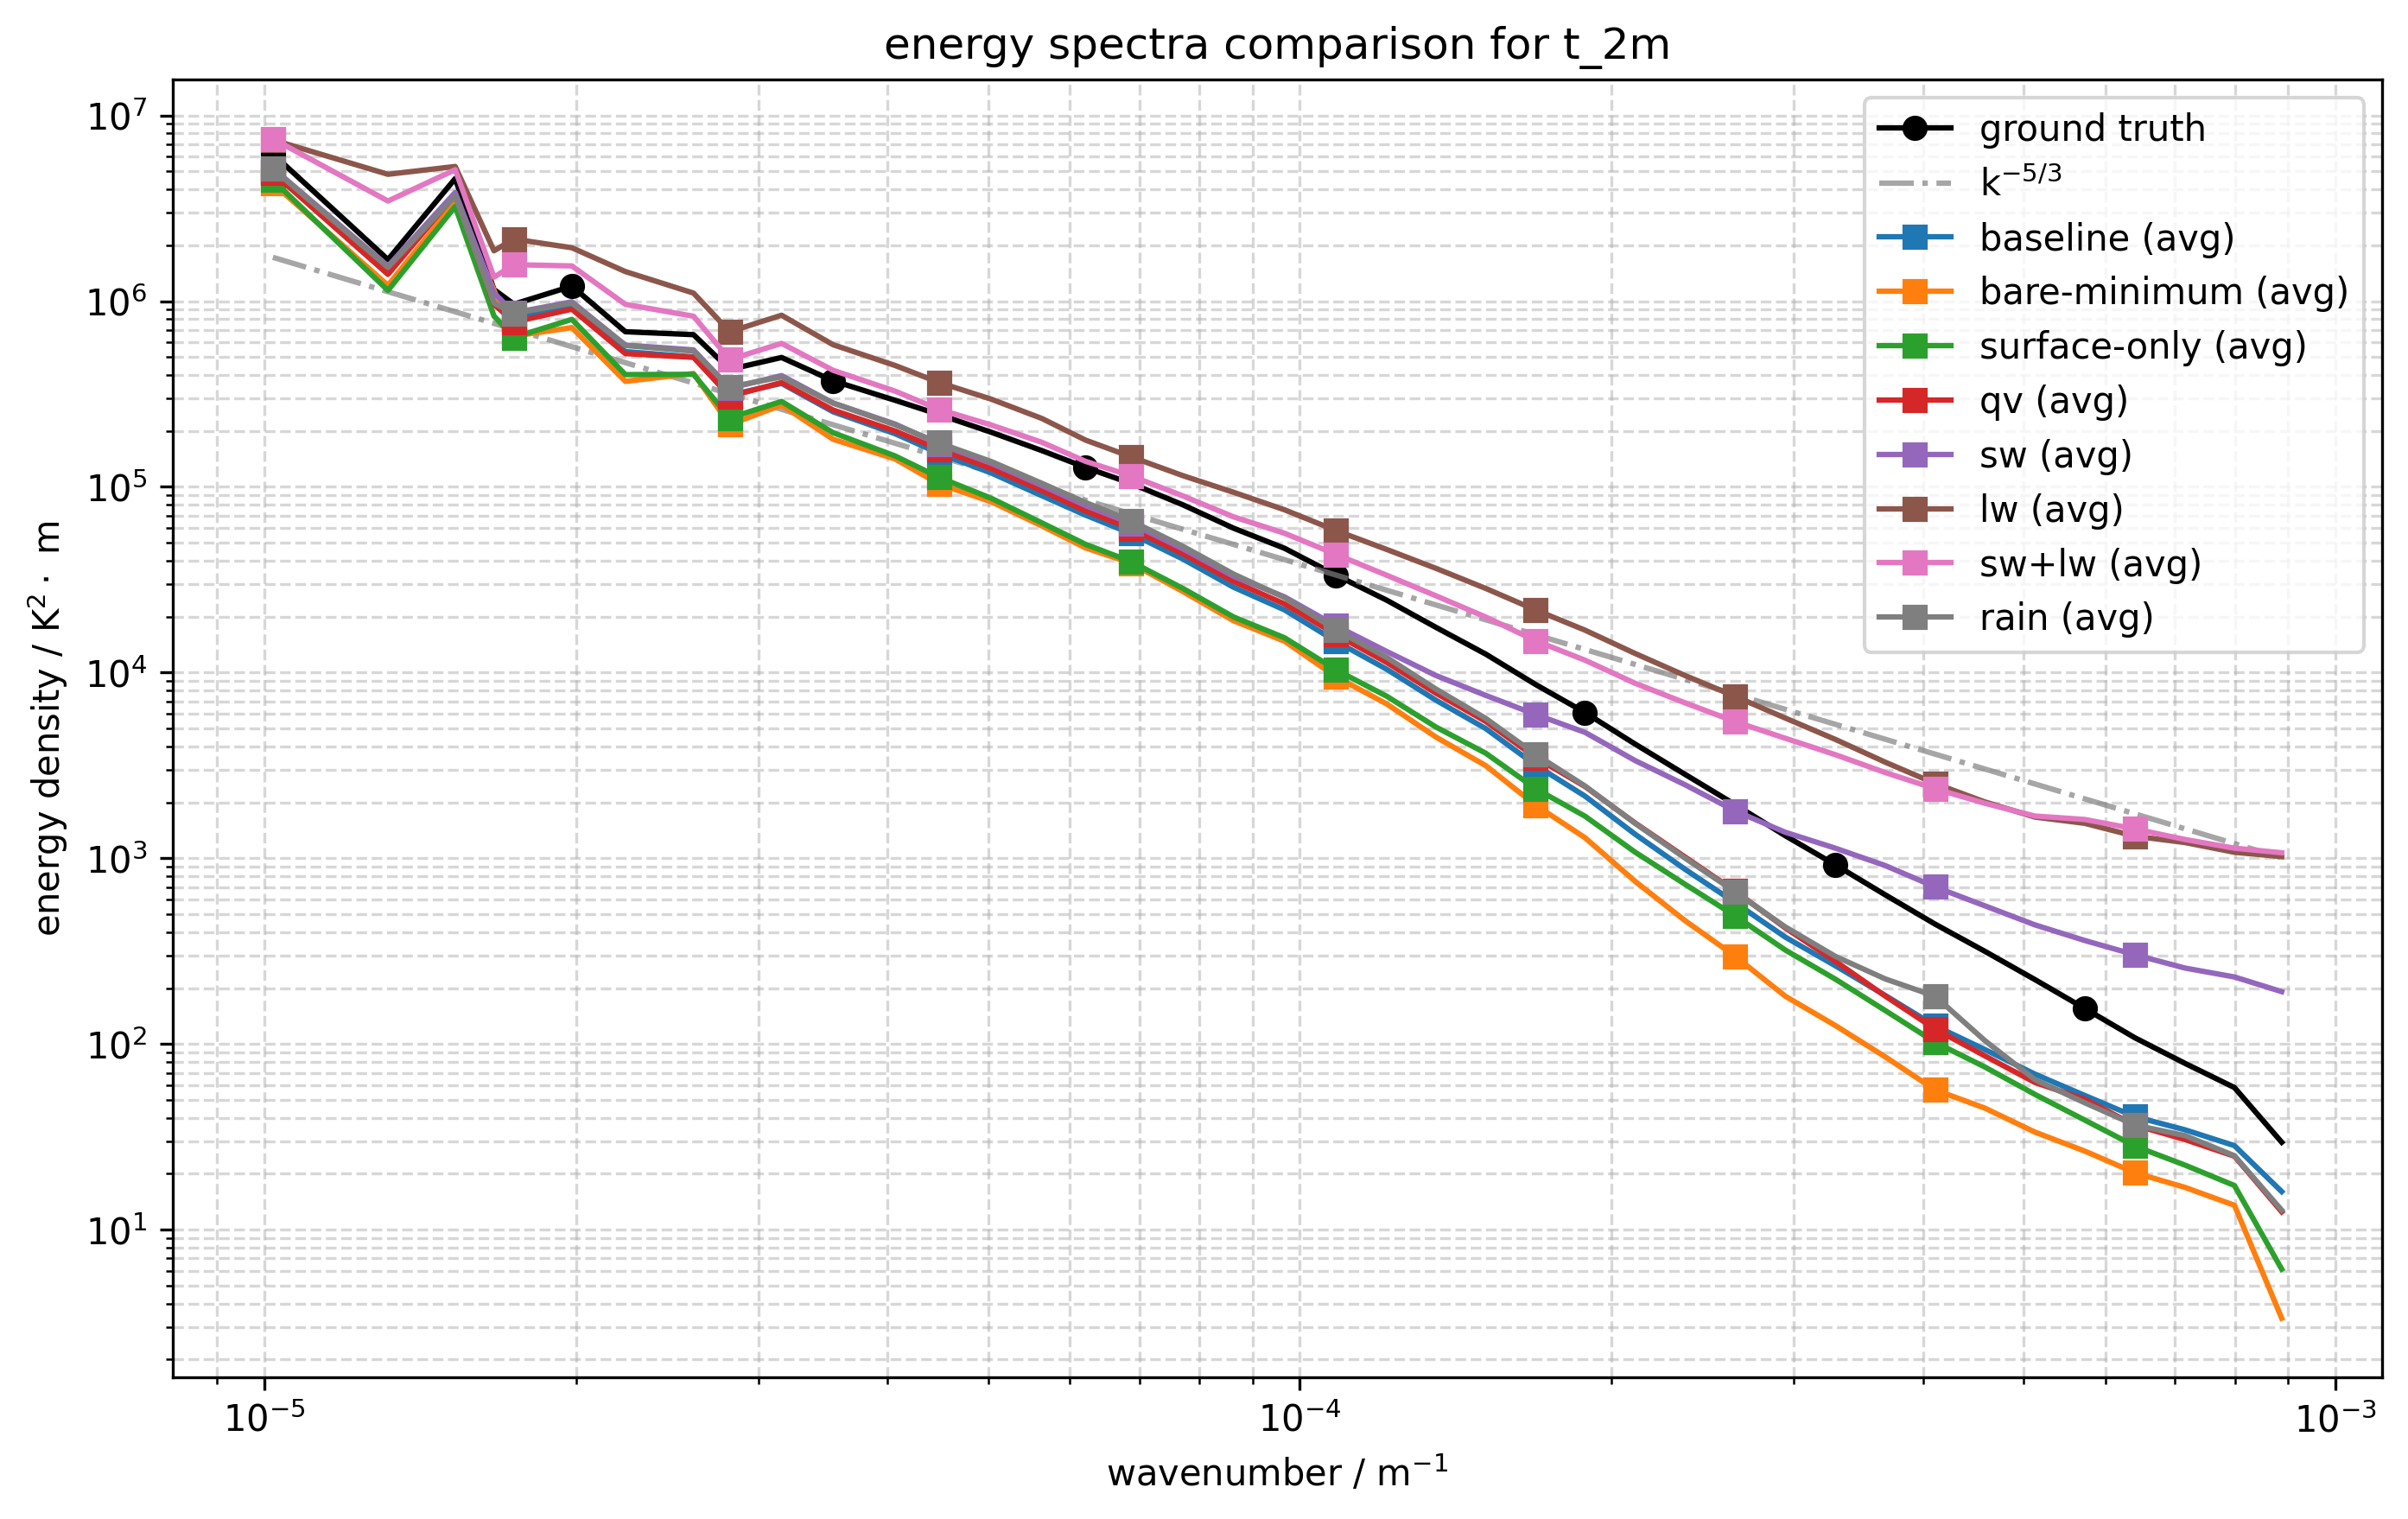

In [8]:
# static (time-averaged) comparison using the same label dictionary
static_labels = {k: v.replace("(300min)", "(avg)") for k, v in labels.items()}

fig = None
ax = None
for name, label in static_labels.items():
    kwargs = dict(show_legend=True, temporal=False, static=True,
                  label=label, add_eff_res=False, add_lsd=False)
    if ax is not None:

        kwargs["ax"] = ax

        kwargs["add_gt"] = False
    fig, ax = es.plot_energy_spectra(caches[name], "t_2m", **kwargs)